In [143]:
# ======================================================
# STEP 1: Install libraries (run once if needed)
# ======================================================

# !pip install pandas numpy matplotlib scipy pymoo

# print("STEP 1 completed successfully.")

In [144]:
# ======================================================
# STEP 2: Import libraries
# ======================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import linprog

from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.termination import get_termination

plt.rcParams["figure.figsize"] = (11, 4)

print("STEP 2 completed successfully.")

STEP 2 completed successfully.


In [145]:
# ======================================================
# STEP 3: Define paths and general parameters
# ======================================================

BASE_PATH = r"/Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset"

ENERGY_FILE = os.path.join(BASE_PATH, "EnergyStreams/id01_merged_30min.csv")
EV_FILE     = os.path.join(BASE_PATH, "JourneyCharge/id01_Sorted_Mobility.csv")

TARGET_DATE = "2021-03-12"
RESAMPLE_RULE = "15min"
DT_HOURS = 15 / 60

CHARGER_KW = 7.4
ETA = 0.95

PRICE_NIGHT = 0.12
PRICE_DAY   = 0.22
PRICE_PEAK  = 0.30

# Main results folder
RESULTS_FOLDER = os.path.join(BASE_PATH, "Simulation_Results_MultiEV_MultiLoad")
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# Subfolders for figures
RAW_FOLDER         = os.path.join(RESULTS_FOLDER, "01_RawInputs")
LOAD_FOLDER        = os.path.join(RESULTS_FOLDER, "02_OverallLoadProfiles")
COST_FOLDER        = os.path.join(RESULTS_FOLDER, "03_CostPlots")
SOC_FOLDER         = os.path.join(RESULTS_FOLDER, "04_SoCPlots")
PARETO_FOLDER      = os.path.join(RESULTS_FOLDER, "05_ParetoPlots")
CONV_FOLDER        = os.path.join(RESULTS_FOLDER, "06_ConvergencePlots")
AGG_FOLDER         = os.path.join(RESULTS_FOLDER, "07_AggregatePlots")

for folder in [RAW_FOLDER, LOAD_FOLDER, COST_FOLDER, SOC_FOLDER, PARETO_FOLDER, CONV_FOLDER, AGG_FOLDER]:
    os.makedirs(folder, exist_ok=True)

print("STEP 3 completed successfully.")
print("Results will be saved in:", RESULTS_FOLDER)

STEP 3 completed successfully.
Results will be saved in: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Simulation_Results_MultiEV_MultiLoad


In [146]:
# ======================================================
# STEP 4: Load and preprocess household load and retail price
# ======================================================

energy_raw = pd.read_csv(ENERGY_FILE)

print("Columns in energy file:")
print(energy_raw.columns.tolist())

energy_raw["time"] = pd.to_datetime(energy_raw["timestamp"], utc=True)
energy_raw["time"] = energy_raw["time"].dt.tz_convert(None)

energy_raw = energy_raw.rename(columns={
    "as230_import_kWh": "house_kwh_30min",
    "elec_price": "price"
})

# 30-minute energy to average power in kW
energy_raw["house_kw"] = energy_raw["house_kwh_30min"] / 0.5

energy_raw = energy_raw[["time", "house_kw", "price"]].copy()

print("\nFirst 5 rows:")
print(energy_raw.head())

print("STEP 4 completed successfully.")

Columns in energy file:
['timestamp', 'id', 'solar_kWh', 'as230_import_kWh', 'as230_export_kWh', 'elec_price', 'heatpump_kWh', 'battery_charge_kWh', 'battery_discharge_kWh', 'battery_soc']

First 5 rows:
                 time  house_kw  price
0 2019-01-25 00:00:00       NaN  0.035
1 2019-01-25 00:30:00       NaN  0.035
2 2019-01-25 01:00:00       NaN  0.035
3 2019-01-25 01:30:00       NaN  0.035
4 2019-01-25 02:00:00       NaN  0.035
STEP 4 completed successfully.


In [147]:
# ======================================================
# STEP 5: Convert to 15-minute resolution
# ======================================================

energy_15 = (
    energy_raw
    .set_index("time")
    .resample(RESAMPLE_RULE)
    .interpolate(method="time")
    .reset_index()
)

target_date = pd.to_datetime(TARGET_DATE).date()
day_df = energy_15[energy_15["time"].dt.date == target_date].copy()

print("Number of 15-minute intervals:", len(day_df))
print(day_df.head())

print("STEP 5 completed successfully.")

Number of 15-minute intervals: 96
                     time  house_kw  price
74592 2021-03-12 00:00:00   1.86150  0.035
74593 2021-03-12 00:15:00   1.39075  0.035
74594 2021-03-12 00:30:00   0.92000  0.035
74595 2021-03-12 00:45:00   1.03050  0.035
74596 2021-03-12 01:00:00   1.14100  0.035
STEP 5 completed successfully.


In [148]:
# ======================================================
# STEP 6: Load EV file and extract one charging session
# ======================================================

ev_raw = pd.read_csv(EV_FILE)

print("Columns in EV file:")
print(ev_raw.columns.tolist())

ev_raw["start_time"] = pd.to_datetime(ev_raw["start_time"])
ev_raw["end_time"] = pd.to_datetime(ev_raw["end_time"])

ev_charge = ev_raw[ev_raw["event_type"].str.lower() == "charging"].copy()

ev_day = ev_charge[ev_charge["start_time"].dt.date == target_date].copy()

if len(ev_day) == 0:
    raise ValueError("No charging session found for TARGET_DATE.")

session = ev_day.iloc[0]

ARRIVAL_TIME = session["start_time"]
DEPARTURE_TIME = session["end_time"]

print("Selected charging session:")
print("Arrival time :", ARRIVAL_TIME)
print("Departure time:", DEPARTURE_TIME)
print("Recorded ENERGY (kWh):", session["ENERGY"])

print("STEP 6 completed successfully.")

Columns in EV file:
['id', 'start_time', 'end_time', 'Distance', 'Duration', 'event_type', 'CHARGING_TIME', 'ENERGY']
Selected charging session:
Arrival time : 2021-03-12 09:22:58
Departure time: 2021-03-12 11:52:49
Recorded ENERGY (kWh): 16.89
STEP 6 completed successfully.


In [149]:
# ======================================================
# STEP 7: Build simulation dataframe with EV availability
# ======================================================

df = day_df.copy()

df["available"] = 0
df.loc[(df["time"] >= ARRIVAL_TIME) & (df["time"] < DEPARTURE_TIME), "available"] = 1

available_hours = df["available"].sum() * DT_HOURS
max_possible_energy = available_hours * CHARGER_KW * ETA

print("Available charging intervals:", df["available"].sum())
print("Available charging hours:", round(available_hours, 4))
print("Maximum possible delivered energy (kWh):", round(max_possible_energy, 4))

print("STEP 7 completed successfully.")
print(df.head())

Available charging intervals: 10
Available charging hours: 2.5
Maximum possible delivered energy (kWh): 17.575
STEP 7 completed successfully.
                     time  house_kw  price  available
74592 2021-03-12 00:00:00   1.86150  0.035          0
74593 2021-03-12 00:15:00   1.39075  0.035          0
74594 2021-03-12 00:30:00   0.92000  0.035          0
74595 2021-03-12 00:45:00   1.03050  0.035          0
74596 2021-03-12 01:00:00   1.14100  0.035          0


In [150]:
# ======================================================
# STEP 8: Add TOU tariff
# ======================================================

def tou_price(ts):
    h = ts.hour
    if 0 <= h < 6:
        return PRICE_NIGHT
    elif 17 <= h < 21:
        return PRICE_PEAK
    else:
        return PRICE_DAY

df["tou_price"] = df["time"].apply(tou_price)

print("STEP 8 completed successfully.")
print(df[["time", "price", "tou_price"]].head())

STEP 8 completed successfully.
                     time  price  tou_price
74592 2021-03-12 00:00:00  0.035       0.12
74593 2021-03-12 00:15:00  0.035       0.12
74594 2021-03-12 00:30:00  0.035       0.12
74595 2021-03-12 00:45:00  0.035       0.12
74596 2021-03-12 01:00:00  0.035       0.12


In [151]:
# ======================================================
# STEP 9: Create three household load profiles
# ======================================================

load_profiles = {
    "SMALL":  0.80 * df["house_kw"].values,
    "MEDIUM": 1.00 * df["house_kw"].values,
    "LARGE":  1.20 * df["house_kw"].values
}

load_profile_info = pd.DataFrame({
    "LoadProfile": ["SMALL", "MEDIUM", "LARGE"],
    "ScaleFactor": [0.80, 1.00, 1.20],
    "MeanLoad_kW": [load_profiles["SMALL"].mean(), load_profiles["MEDIUM"].mean(), load_profiles["LARGE"].mean()],
    "PeakLoad_kW": [load_profiles["SMALL"].max(), load_profiles["MEDIUM"].max(), load_profiles["LARGE"].max()]
})

print("STEP 9 completed successfully.")
load_profile_info

STEP 9 completed successfully.


,LoadProfile,ScaleFactor,MeanLoad_kW,PeakLoad_kW
0,SMALL,0.8,1.453283,7.340
1,MEDIUM,1.0,1.816604,9.175
2,LARGE,1.2,2.179925,11.010


In [152]:
# ======================================================
# STEP 10: Define feasible EV scenarios
# ======================================================

print("Maximum possible delivered energy in this charging window (kWh):", round(max_possible_energy, 4))

ev_scenarios = [
    {
        "EV_Name": "Nissan LEAF",
        "EV_Abbr": "LEAF40",
        "Battery_kWh": 40.0,
        "SOC_Init": 0.35,
        "SOC_Target": 0.70
    },
    {
        "EV_Name": "Tesla S",
        "EV_Abbr": "TS60",
        "Battery_kWh": 60.0,
        "SOC_Init": 0.45,
        "SOC_Target": 0.70
    },
    {
        "EV_Name": "Tesla Model 3",
        "EV_Abbr": "TM3_80",
        "Battery_kWh": 80.5,
        "SOC_Init": 0.50,
        "SOC_Target": 0.70
    },
    {
        "EV_Name": "Tesla Model X",
        "EV_Abbr": "TMX100",
        "Battery_kWh": 100.0,
        "SOC_Init": 0.55,
        "SOC_Target": 0.70
    }
]

scenario_df = pd.DataFrame(ev_scenarios)
scenario_df["RequiredEnergy_kWh"] = (
    (scenario_df["SOC_Target"] - scenario_df["SOC_Init"]) * scenario_df["Battery_kWh"]
)
scenario_df["MaxPossibleEnergy_kWh"] = max_possible_energy
scenario_df["Feasible"] = scenario_df["RequiredEnergy_kWh"] <= max_possible_energy + 1e-9

print("STEP 10 completed successfully.")
scenario_df

Maximum possible delivered energy in this charging window (kWh): 17.575
STEP 10 completed successfully.


,EV_Name,EV_Abbr,Battery_kWh,SOC_Init,SOC_Target,RequiredEnergy_kWh,MaxPossibleEnergy_kWh,Feasible
0,Nissan LEAF,LEAF40,40.0,0.35,0.7,14.0,17.575,True
1,Tesla S,TS60,60.0,0.45,0.7,15.0,17.575,True
2,Tesla Model 3,TM3_80,80.5,0.50,0.7,16.1,17.575,True
3,Tesla Model X,TMX100,100.0,0.55,0.7,15.0,17.575,True


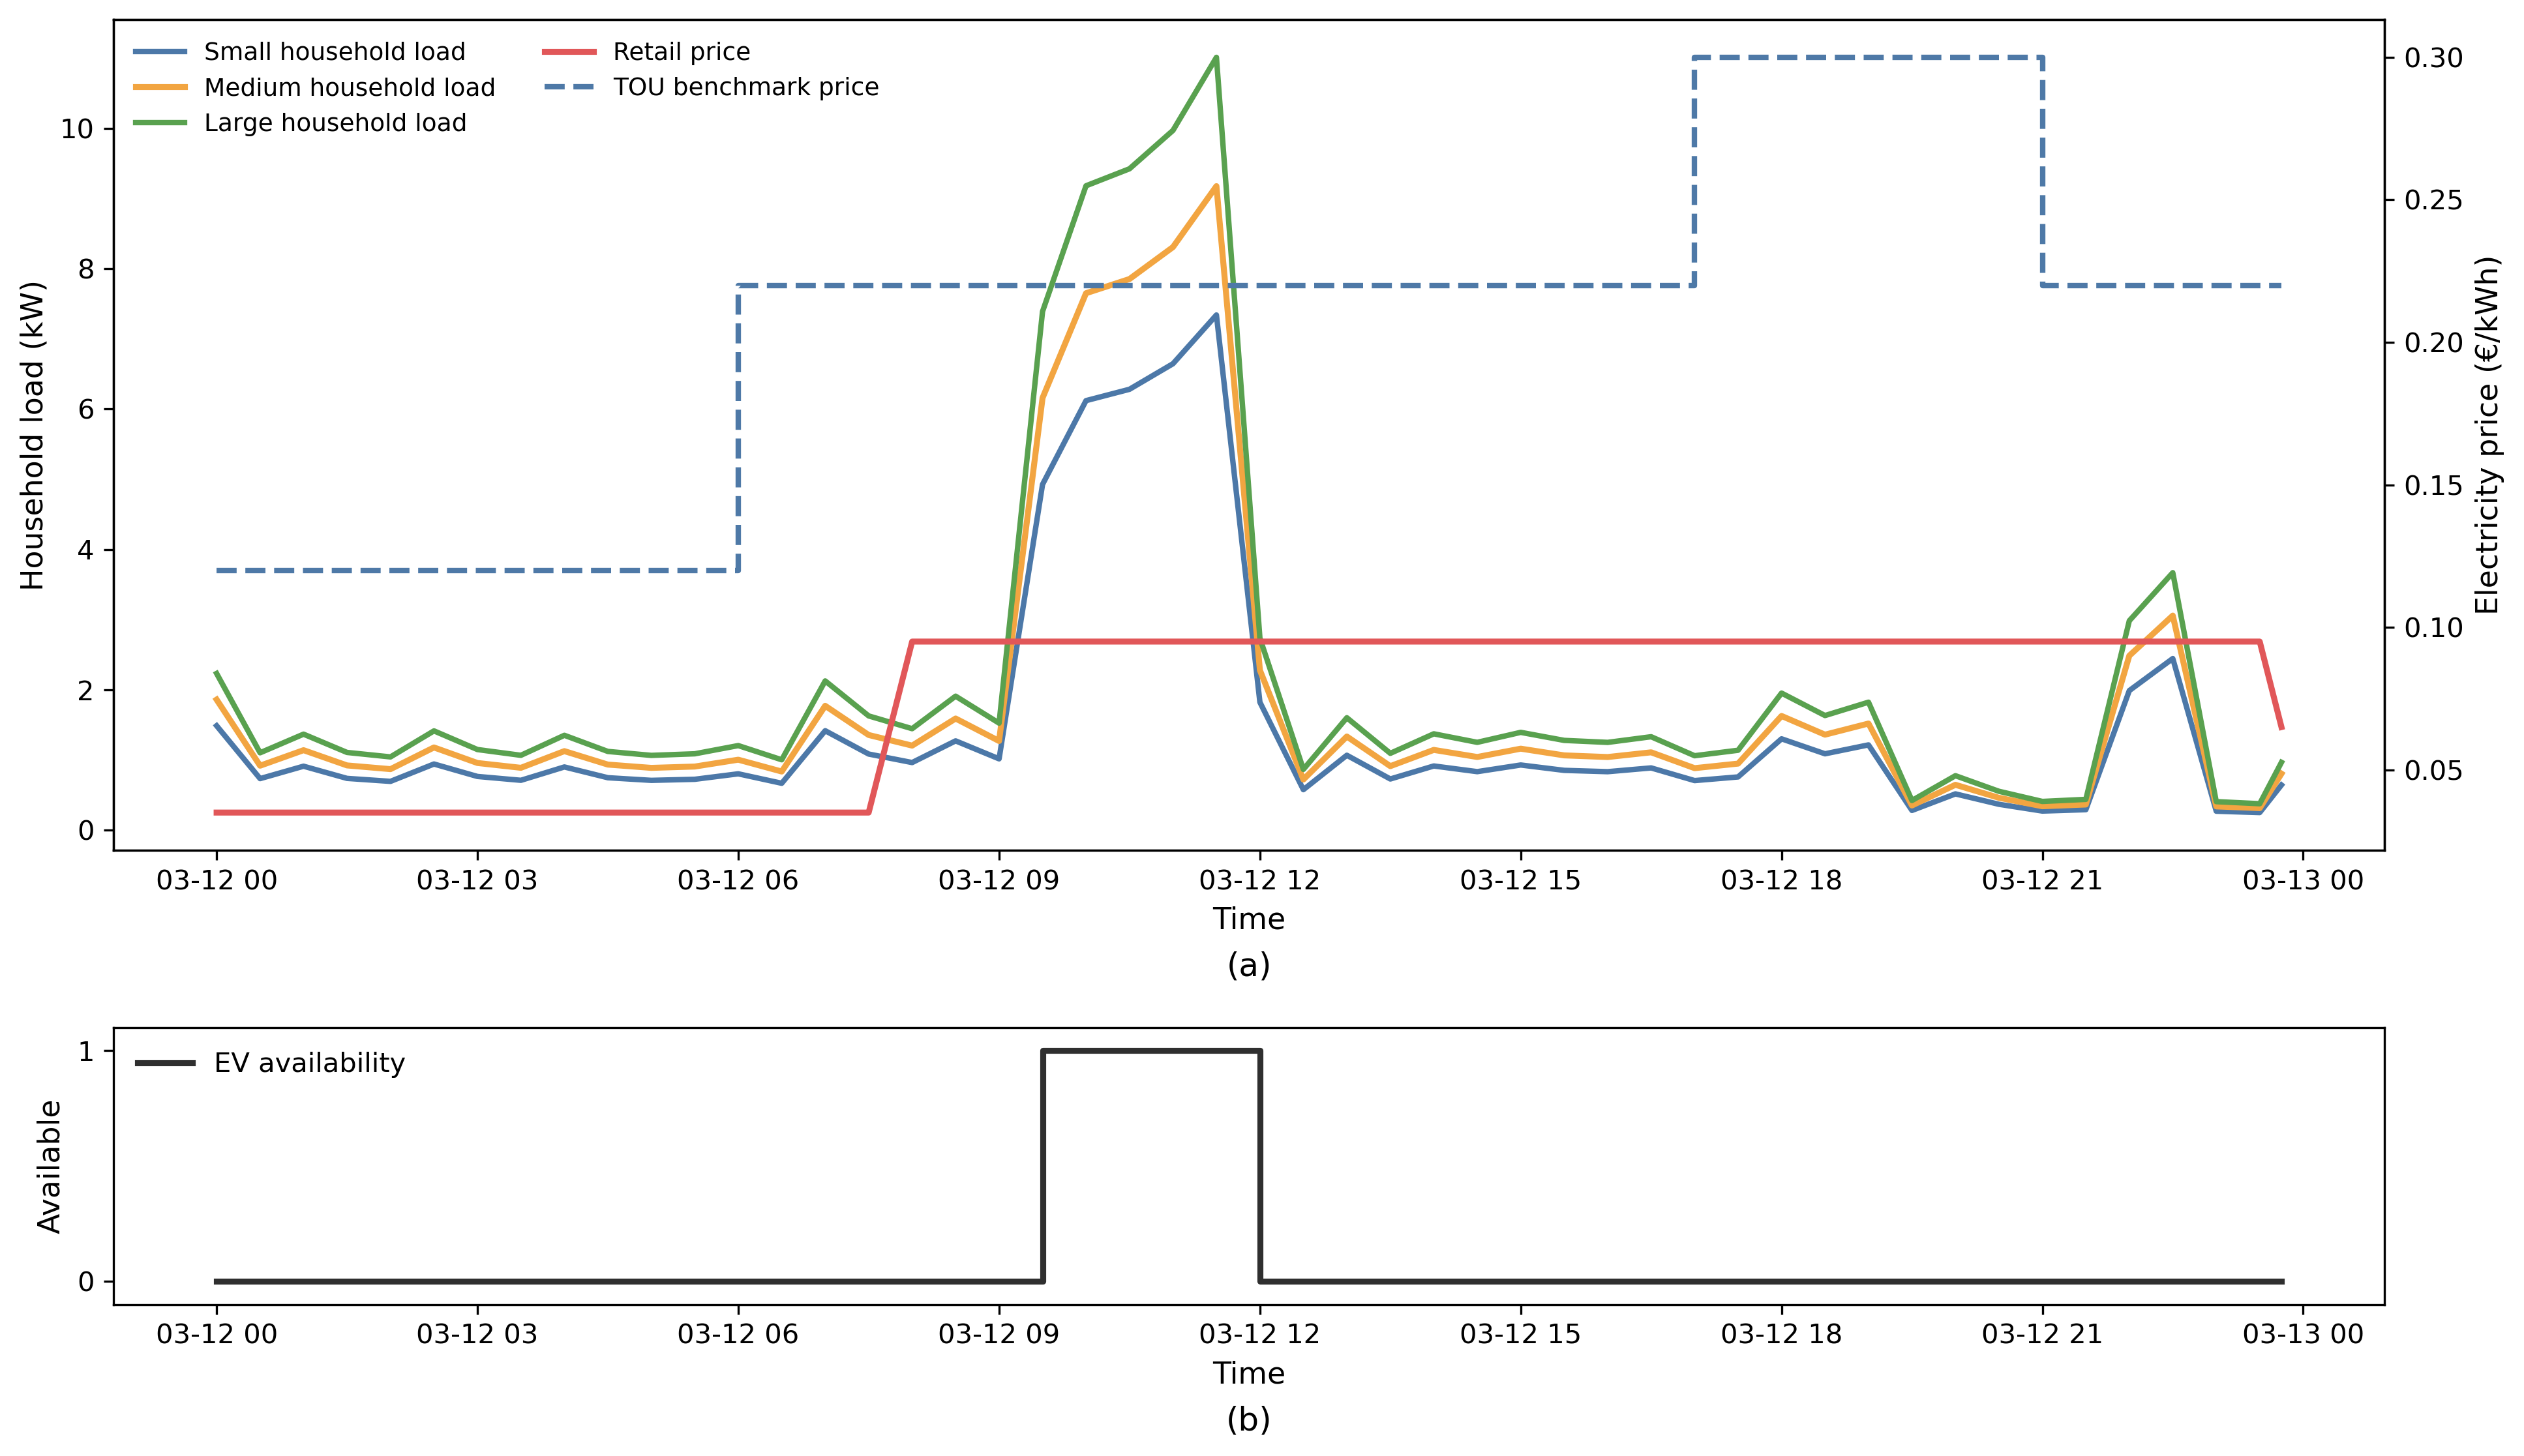

STEP 11 completed successfully.


In [153]:
# ======================================================
# STEP 11: Plot raw inputs load and cost for the three households
# ======================================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(13, 7.5),
    dpi=300,
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# =========================
# Top panel: load profiles + prices
# =========================

line1, = ax1.plot(
    df["time"], load_profiles["SMALL"],
    linewidth=2.0,
    color="#4C78A8",   # blue
    label="Small household load"
)

line2, = ax1.plot(
    df["time"], load_profiles["MEDIUM"],
    linewidth=2.2,
    color="#F2A541",   # softer orange (less harsh)
    label="Medium household load"
)

line3, = ax1.plot(
    df["time"], load_profiles["LARGE"],
    linewidth=2.0,
    color="#59A14F",   # balanced green
    label="Large household load"
)

ax1.set_ylabel("Household load (kW)", fontsize=11)
ax1.set_xlabel("Time", fontsize=11)
ax1.tick_params(axis="x", labelbottom=True)

# Right axis for prices
ax1b = ax1.twinx()

line4, = ax1b.plot(
    df["time"], df["price"],
    linewidth=2.2,
    color="#E15759",   # strong red for real price
    label="Retail price"
)

line5, = ax1b.step(
    df["time"], df["tou_price"],
    where="post",
    linewidth=2.0,
    linestyle="--",
    color="#4E79A7",   # 👈 switched to blue (clear contrast)
    label="TOU benchmark price"
)

ax1b.set_ylabel("Electricity price (€/kWh)", fontsize=11)

# Combined legend
lines_top = [line1, line2, line3, line4, line5]
labels_top = [l.get_label() for l in lines_top]

ax1.legend(
    lines_top,
    labels_top,
    loc="upper left",
    frameon=False,
    fontsize=9,
    ncol=2
)

ax1.grid(False)
ax1b.grid(False)

# Panel label
ax1.text(
    0.5, -0.14, "(a)",
    transform=ax1.transAxes,
    ha="center",
    va="center",
    fontsize=12
)

# =========================
# Bottom panel: EV availability
# =========================

ax2.step(
    df["time"], df["available"],
    where="post",
    linewidth=2.2,
    color="#2F2F2F",   # darker neutral (better than blue/black clash)
    label="EV availability"
)

ax2.set_ylabel("Available", fontsize=11)
ax2.set_xlabel("Time", fontsize=11)
ax2.set_ylim(-0.1, 1.1)
ax2.set_yticks([0, 1])

ax2.legend(loc="upper left", frameon=False, fontsize=10)
ax2.grid(False)

ax2.text(
    0.5, -0.42, "(b)",
    transform=ax2.transAxes,
    ha="center",
    va="center",
    fontsize=12
)

# =========================
# Layout and save
# =========================

plt.xticks(rotation=45)
plt.tight_layout()
plt.subplots_adjust(hspace=0.32)

plt.savefig(
    os.path.join(RAW_FOLDER, "raw_inputs_all_load_profiles.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print("STEP 11 completed successfully.")

In [154]:
# ======================================================
# STEP 12: Define helper functions
# ======================================================

METHOD_ORDER = ["Base", "UC", "TOU", "SCM", "SPM", "MOCF-IoEVs"]

def build_scenario_inputs(df, battery_kwh, soc_init, soc_target):
    e_req = (soc_target - soc_init) * battery_kwh
    available_hours_local = df["available"].sum() * DT_HOURS
    max_possible_energy_local = available_hours_local * CHARGER_KW * ETA
    feasible = e_req <= max_possible_energy_local + 1e-9

    return {
        "Battery_kWh": battery_kwh,
        "SOC_Init": soc_init,
        "SOC_Target": soc_target,
        "E_REQ": e_req,
        "AvailableHours": available_hours_local,
        "MaxPossibleEnergy": max_possible_energy_local,
        "Feasible": feasible
    }

def simulate_soc(ev_kw, soc_init, battery_kwh):
    soc = np.zeros(len(ev_kw) + 1)
    soc[0] = soc_init
    for t in range(len(ev_kw)):
        soc[t + 1] = soc[t] + (ETA * ev_kw[t] * DT_HOURS) / battery_kwh
    return soc

def summarize_case(load_name, ev_name, ev_abbr, battery_kwh, soc_init, soc_target,
                   method_name, method_abbr, house_kw, ev_kw, price, e_req):
    total_kw = house_kw + ev_kw
    delivered = np.sum(ev_kw * DT_HOURS * ETA)
    soc = simulate_soc(ev_kw, soc_init, battery_kwh)

    return {
        "LoadProfile": load_name,
        "Scenario": ev_name,
        "ScenarioAbbr": ev_abbr,
        "Battery_kWh": battery_kwh,
        "SOC_Init": soc_init,
        "SOC_Target": soc_target,
        "Method": method_name,
        "MethodAbbr": method_abbr,
        "ChargingCost": np.sum(ev_kw * price * DT_HOURS),
        "PeakTotalLoad_kW": np.max(total_kw),
        "DeliveredEnergy_kWh": delivered,
        "RequiredEnergy_kWh": e_req,
        "FinalSoC": soc[-1],
        "Completed": delivered + 1e-6 >= e_req
    }

def uncontrolled_charging(df, e_req):
    ev_kw = np.zeros(len(df))
    delivered = 0.0

    for t in range(len(df)):
        if df["available"].iloc[t] == 1 and delivered < e_req:
            ev_kw[t] = CHARGER_KW
            delivered += ETA * ev_kw[t] * DT_HOURS

            if delivered > e_req:
                excess = delivered - e_req
                reduce_power = excess / (ETA * DT_HOURS)
                ev_kw[t] = max(ev_kw[t] - reduce_power, 0.0)
                delivered = e_req

    return ev_kw

def tou_charging(df, e_req):
    ev_kw = np.zeros(len(df))
    available_idx = np.where(df["available"].values == 1)[0]

    energy_needed_wall = e_req / ETA
    slot_energy = CHARGER_KW * DT_HOURS

    sorted_idx = available_idx[np.argsort(df["tou_price"].values[available_idx])]

    remaining = energy_needed_wall
    for idx in sorted_idx:
        if remaining <= 1e-9:
            break
        charge_energy = min(slot_energy, remaining)
        ev_kw[idx] = charge_energy / DT_HOURS
        remaining -= charge_energy

    return ev_kw

def cost_minimization_lp(df, e_req):
    c = df["price"].values * DT_HOURS

    bounds = [(0, CHARGER_KW) if avail == 1 else (0, 0) for avail in df["available"].values]

    A_ub = np.array([-(ETA * DT_HOURS) * np.ones(len(df))])
    b_ub = np.array([-e_req])

    result = linprog(c=c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
    if not result.success:
        raise RuntimeError("Cost minimization LP failed: " + result.message)

    return result.x

def peak_minimization_lp(df, house_kw, e_req):
    n = len(df)

    c = np.zeros(n + 1)
    c[-1] = 1.0

    bounds = [(0, CHARGER_KW) if avail == 1 else (0, 0) for avail in df["available"].values]
    bounds.append((0, None))

    A_ub = []
    b_ub = []

    for t in range(n):
        row = np.zeros(n + 1)
        row[t] = 1.0
        row[-1] = -1.0
        A_ub.append(row)
        b_ub.append(-house_kw[t])

    row = np.zeros(n + 1)
    row[:n] = -(ETA * DT_HOURS)
    A_ub.append(row)
    b_ub.append(-e_req)

    result = linprog(
        c=c,
        A_ub=np.array(A_ub),
        b_ub=np.array(b_ub),
        bounds=bounds,
        method="highs"
    )

    if not result.success:
        raise RuntimeError("Peak minimization LP failed: " + result.message)

    return result.x[:n]

class MOCFProblem(Problem):
    def __init__(self, df, house_kw, e_req):
        self.house_kw = house_kw
        self.price = df["price"].values
        self.available = df["available"].values
        self.e_req = e_req

        xl = np.zeros(len(df))
        xu = np.where(self.available == 1, CHARGER_KW, 0.0)

        super().__init__(n_var=len(df), n_obj=2, n_constr=1, xl=xl, xu=xu)

    def _evaluate(self, X, out, *args, **kwargs):
        f1 = np.sum(X * self.price * DT_HOURS, axis=1)
        total_kw = X + self.house_kw[None, :]
        f2 = np.max(total_kw, axis=1)

        delivered = np.sum(X * DT_HOURS * ETA, axis=1)
        g1 = self.e_req - delivered

        out["F"] = np.column_stack([f1, f2])
        out["G"] = np.column_stack([g1])

def mocf_compromise(df, house_kw, e_req):
    problem = MOCFProblem(df, house_kw, e_req)

    algorithm = NSGA2(pop_size=120)
    termination = get_termination("n_gen", 150)

    res = minimize(
        problem,
        algorithm,
        termination,
        seed=42,
        save_history=True,
        verbose=False
    )

    F = res.F
    X = res.X

    F_norm = (F - F.min(axis=0)) / (F.max(axis=0) - F.min(axis=0) + 1e-12)
    idx_comp = np.argmin(np.sum(F_norm, axis=1))

    history_best_cost = []
    history_best_peak = []

    for algo in res.history:
        pop_F = algo.pop.get("F")
        history_best_cost.append(np.min(pop_F[:, 0]))
        history_best_peak.append(np.min(pop_F[:, 1]))

    return X[idx_comp], F, X, history_best_cost, history_best_peak

print("STEP 12 completed successfully.")

STEP 12 completed successfully.


In [155]:
# ======================================================
# STEP 13: Run all combinations and collect outputs
# ======================================================

scenario_results = []
case_outputs = {}

for load_name, house_kw in load_profiles.items():
    for sc in ev_scenarios:
        ev_name = sc["EV_Name"]
        ev_abbr = sc["EV_Abbr"]
        battery_kwh = sc["Battery_kWh"]
        soc_init = sc["SOC_Init"]
        soc_target = sc["SOC_Target"]

        inputs = build_scenario_inputs(df, battery_kwh, soc_init, soc_target)

        print(f"\nRunning: Load={load_name}, EV={ev_abbr}")
        print(inputs)

        if not inputs["Feasible"]:
            print("Skipped because infeasible.")
            continue

        e_req = inputs["E_REQ"]

        # Base
        ev_base = np.zeros(len(df))
        scenario_results.append(
            summarize_case(
                load_name, ev_name, ev_abbr, battery_kwh, soc_init, soc_target,
                "Base", "Base", house_kw, ev_base, df["price"].values, 0.0
            )
        )

        # UC
        ev_uc = uncontrolled_charging(df, e_req)
        scenario_results.append(
            summarize_case(
                load_name, ev_name, ev_abbr, battery_kwh, soc_init, soc_target,
                "Uncontrolled", "UC", house_kw, ev_uc, df["price"].values, e_req
            )
        )

        # TOU
        ev_tou = tou_charging(df, e_req)
        scenario_results.append(
            summarize_case(
                load_name, ev_name, ev_abbr, battery_kwh, soc_init, soc_target,
                "TOU charging", "TOU", house_kw, ev_tou, df["tou_price"].values, e_req
            )
        )

        # SCM
        ev_cm = cost_minimization_lp(df, e_req)
        scenario_results.append(
            summarize_case(
                load_name, ev_name, ev_abbr, battery_kwh, soc_init, soc_target,
                "Single-objective cost minimization", "SCM", house_kw, ev_cm, df["price"].values, e_req
            )
        )

        # SPM
        ev_pm = peak_minimization_lp(df, house_kw, e_req)
        scenario_results.append(
            summarize_case(
                load_name, ev_name, ev_abbr, battery_kwh, soc_init, soc_target,
                "Single-objective peak minimization", "SPM", house_kw, ev_pm, df["price"].values, e_req
            )
        )

        # MOCF-IoEVs
        ev_mocf, F, X, hist_cost, hist_peak = mocf_compromise(df, house_kw, e_req)
        scenario_results.append(
            summarize_case(
                load_name, ev_name, ev_abbr, battery_kwh, soc_init, soc_target,
                "MOCF-IoEVs (compromise)", "MOCF-IoEVs", house_kw, ev_mocf, df["price"].values, e_req
            )
        )

        case_outputs[(load_name, ev_abbr)] = {
            "house_kw": house_kw,
            "battery_kwh": battery_kwh,
            "soc_init": soc_init,
            "soc_target": soc_target,
            "e_req": e_req,
            "profiles": {
                "Base": ev_base,
                "UC": ev_uc,
                "TOU": ev_tou,
                "SCM": ev_cm,
                "SPM": ev_pm,
                "MOCF-IoEVs": ev_mocf
            },
            "pareto_F": F,
            "pareto_X": X,
            "hist_cost": hist_cost,
            "hist_peak": hist_peak
        }

scenario_results_df = pd.DataFrame(scenario_results)

if len(scenario_results_df) == 0:
    raise ValueError("No feasible cases were solved. Please revise the EV SoC settings.")

print("Rows in scenario_results_df:", len(scenario_results_df))
print(scenario_results_df.head(10))
print("STEP 13 completed successfully.")


Running: Load=SMALL, EV=LEAF40
{'Battery_kWh': 40.0, 'SOC_Init': 0.35, 'SOC_Target': 0.7, 'E_REQ': 14.0, 'AvailableHours': 2.5, 'MaxPossibleEnergy': 17.575, 'Feasible': True}

Running: Load=SMALL, EV=TS60
{'Battery_kWh': 60.0, 'SOC_Init': 0.45, 'SOC_Target': 0.7, 'E_REQ': 14.999999999999996, 'AvailableHours': 2.5, 'MaxPossibleEnergy': 17.575, 'Feasible': True}

Running: Load=SMALL, EV=TM3_80
{'Battery_kWh': 80.5, 'SOC_Init': 0.5, 'SOC_Target': 0.7, 'E_REQ': 16.099999999999998, 'AvailableHours': 2.5, 'MaxPossibleEnergy': 17.575, 'Feasible': True}

Running: Load=SMALL, EV=TMX100
{'Battery_kWh': 100.0, 'SOC_Init': 0.55, 'SOC_Target': 0.7, 'E_REQ': 14.999999999999991, 'AvailableHours': 2.5, 'MaxPossibleEnergy': 17.575, 'Feasible': True}

Running: Load=MEDIUM, EV=LEAF40
{'Battery_kWh': 40.0, 'SOC_Init': 0.35, 'SOC_Target': 0.7, 'E_REQ': 14.0, 'AvailableHours': 2.5, 'MaxPossibleEnergy': 17.575, 'Feasible': True}

Running: Load=MEDIUM, EV=TS60
{'Battery_kWh': 60.0, 'SOC_Init': 0.45, 'SOC_Tar

In [156]:
# ======================================================
# STEP 14: Add peak reduction and cost change metrics
# ======================================================

scenario_results_df["PeakReduction_%"] = np.nan
scenario_results_df["CostChange_%"] = np.nan

existing_cases = (
    scenario_results_df[["LoadProfile", "ScenarioAbbr"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)

for load_name, ev_abbr in existing_cases:
    mask = (
        (scenario_results_df["LoadProfile"] == load_name) &
        (scenario_results_df["ScenarioAbbr"] == ev_abbr)
    )

    uc_peak = scenario_results_df.loc[
        mask & (scenario_results_df["MethodAbbr"] == "UC"),
        "PeakTotalLoad_kW"
    ]

    uc_cost = scenario_results_df.loc[
        mask & (scenario_results_df["MethodAbbr"] == "UC"),
        "ChargingCost"
    ]

    if len(uc_peak) == 0 or len(uc_cost) == 0:
        continue

    peak_uc = uc_peak.iloc[0]
    cost_uc = uc_cost.iloc[0]

    if abs(peak_uc) < 1e-12:
        scenario_results_df.loc[mask, "PeakReduction_%"] = np.nan
    else:
        scenario_results_df.loc[mask, "PeakReduction_%"] = (
            (peak_uc - scenario_results_df.loc[mask, "PeakTotalLoad_kW"]) / peak_uc * 100
        )

    if abs(cost_uc) < 1e-12:
        scenario_results_df.loc[mask, "CostChange_%"] = np.nan
    else:
        scenario_results_df.loc[mask, "CostChange_%"] = (
            (scenario_results_df.loc[mask, "ChargingCost"] - cost_uc) / cost_uc * 100
        )

print("STEP 14 completed successfully.")
scenario_results_df.head(12)
# print(scenario_results_df)

STEP 14 completed successfully.


,LoadProfile,Scenario,ScenarioAbbr,Battery_kWh,SOC_Init,SOC_Target,Method,MethodAbbr,ChargingCost,PeakTotalLoad_kW,DeliveredEnergy_kWh,RequiredEnergy_kWh,FinalSoC,Completed,PeakReduction_%,CostChange_%
0,SMALL,Nissan LEAF,LEAF40,40.0,0.35,0.7,Base,Base,0.000000,7.340000,0.000000,0.0,0.350000,True,4.809114e+01,-1.000000e+02
1,SMALL,Nissan LEAF,LEAF40,40.0,0.35,0.7,Uncontrolled,UC,1.400000,14.140168,14.000000,14.0,0.700000,True,0.000000e+00,0.000000e+00
2,SMALL,Nissan LEAF,LEAF40,40.0,0.35,0.7,TOU charging,TOU,3.242105,14.140168,14.000000,14.0,0.700000,True,-1.004999e-13,1.315789e+02
3,SMALL,Nissan LEAF,LEAF40,40.0,0.35,0.7,Single-objective cost minimization,SCM,1.400000,14.740000,14.000000,14.0,0.700000,True,-4.242040e+00,0.000000e+00
4,SMALL,Nissan LEAF,LEAF40,40.0,0.35,0.7,Single-objective peak minimization,SPM,1.400000,12.004663,14.000000,14.0,0.700000,True,1.510240e+01,-1.586033e-14
5,SMALL,Nissan LEAF,LEAF40,40.0,0.35,0.7,MOCF-IoEVs (compromise),MOCF-IoEVs,1.400013,12.338195,14.000133,14.0,0.700003,True,1.274365e+01,9.526056e-04
6,SMALL,Tesla S,TS60,60.0,0.45,0.7,Base,Base,0.000000,7.340000,0.000000,0.0,0.450000,True,4.900228e+01,-1.000000e+02
7,SMALL,Tesla S,TS60,60.0,0.45,0.7,Uncontrolled,UC,1.500000,14.392800,15.000000,15.0,0.700000,True,0.000000e+00,0.000000e+00
8,SMALL,Tesla S,TS60,60.0,0.45,0.7,TOU charging,TOU,3.473684,14.392800,15.000000,15.0,0.700000,True,0.000000e+00,1.315789e+02
9,SMALL,Tesla S,TS60,60.0,0.45,0.7,Single-objective cost minimization,SCM,1.500000,14.740000,15.000000,15.0,0.700000,True,-2.412317e+00,0.000000e+00


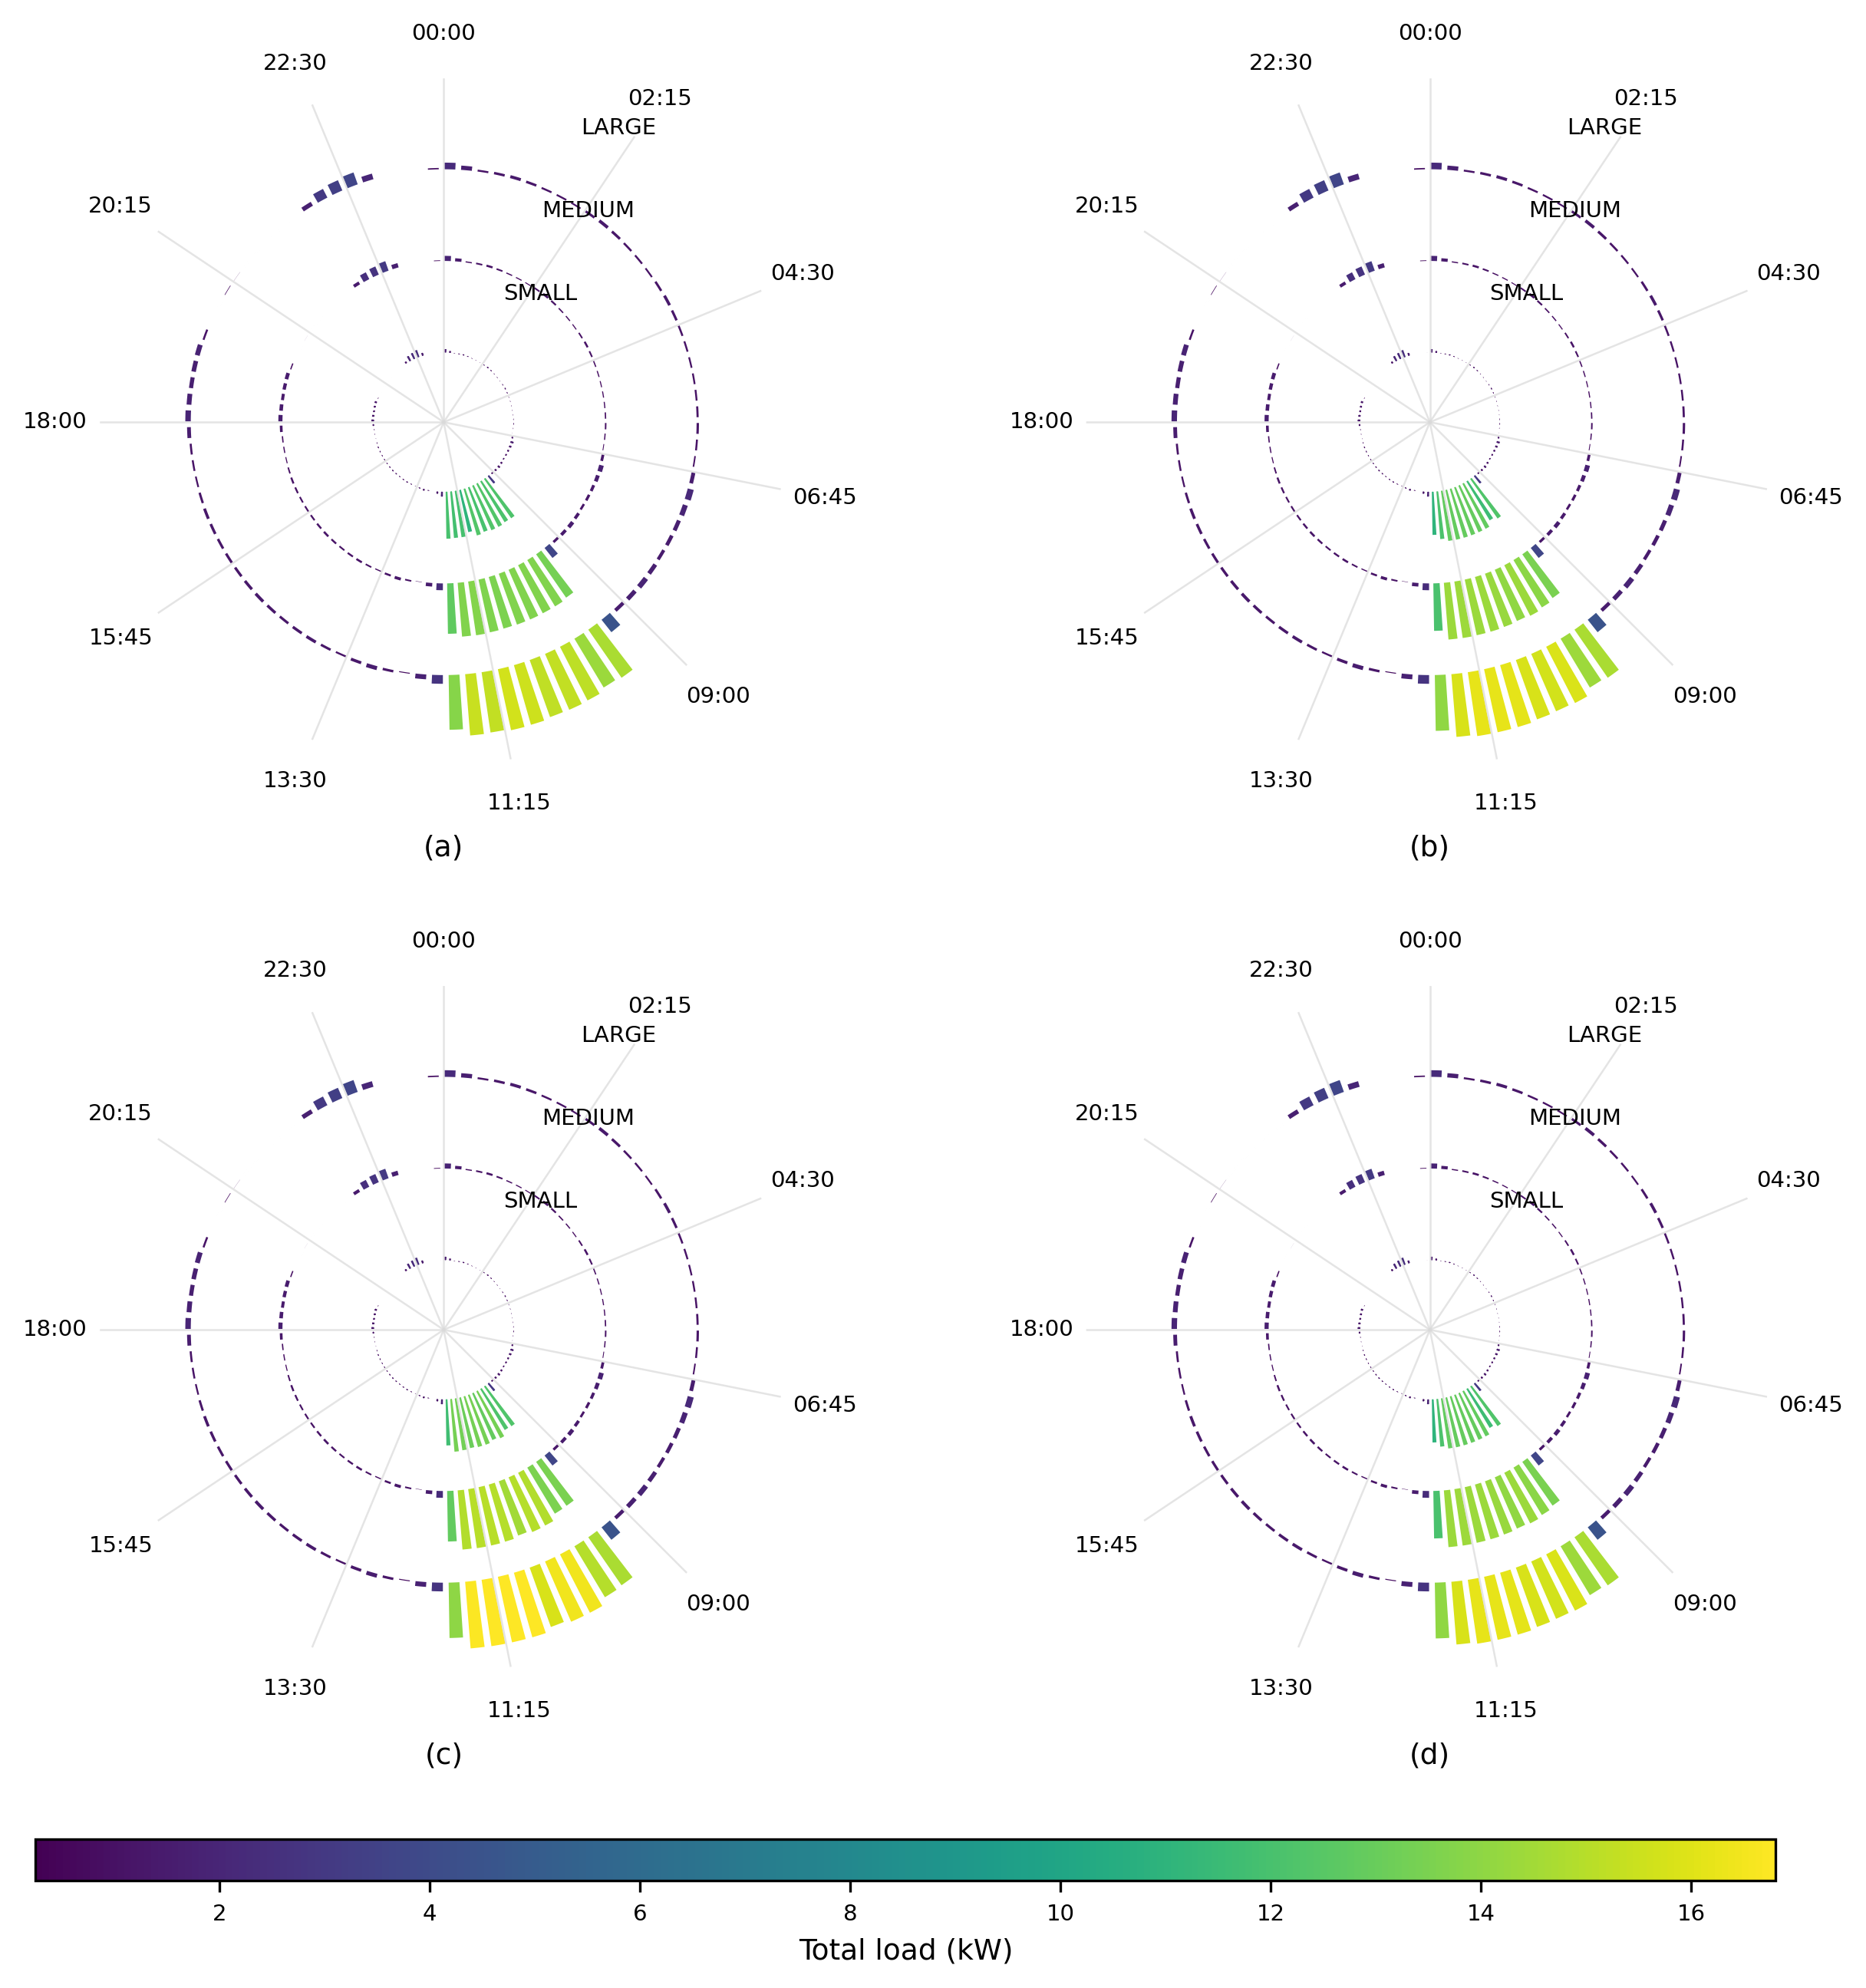

STEP 15 completed successfully.


In [157]:
# ======================================================
# STEP 15: Plot the load with each method for each EV type
# ======================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# -----------------------------
# USER CHOICE
# -----------------------------
selected_method = "MOCF-IoEVs"

# -----------------------------
# SETTINGS
# -----------------------------
ev_order = ["LEAF40", "TS60", "TM3_80", "TMX100"]
load_order = ["SMALL", "MEDIUM", "LARGE"]

panel_labels = {
    "LEAF40": "(a)",
    "TS60": "(b)",
    "TM3_80": "(c)",
    "TMX100": "(d)"
}

# -----------------------------
# TIME AXIS
# -----------------------------
time_values = df["time"].values
n_time = len(time_values)

theta = np.linspace(0, 2 * np.pi, n_time, endpoint=False)
bar_width = 2 * np.pi / n_time * 0.75

tick_step = max(1, n_time // 10)
tick_idx = np.arange(0, n_time, tick_step)
tick_theta = theta[tick_idx]
tick_labels = [str(t)[11:16] for t in time_values[tick_idx]]

# -----------------------------
# GLOBAL RANGE
# -----------------------------
all_loads = []

for ev in ev_order:
    for load in load_order:
        key = (load, ev)
        if key not in case_outputs:
            continue
        if selected_method not in case_outputs[key]["profiles"]:
            continue

        out = case_outputs[key]
        total = np.asarray(out["house_kw"]) + np.asarray(out["profiles"][selected_method])
        all_loads.extend(total)

if len(all_loads) == 0:
    raise ValueError(f"No load data found for selected_method = '{selected_method}'.")

global_min = np.min(all_loads)
global_max = np.max(all_loads)

norm = mpl.colors.Normalize(vmin=global_min, vmax=global_max)
cmap = plt.cm.viridis

# -----------------------------
# RING SETTINGS
# -----------------------------
ring_bottoms = {
    "SMALL": 0.9,
    "MEDIUM": 2.1,
    "LARGE": 3.3
}
ring_max_height = 0.9

ring_label_r = {
    k: v + ring_max_height + 0.05 for k, v in ring_bottoms.items()
}

# -----------------------------
# FIGURE
# -----------------------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(9, 9),
    dpi=300,
    subplot_kw={"projection": "polar"}
)
axes = axes.flatten()

for idx, ev in enumerate(ev_order):
    ax = axes[idx]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    for load in load_order:
        key = (load, ev)
        if key not in case_outputs:
            continue
        if selected_method not in case_outputs[key]["profiles"]:
            continue

        out = case_outputs[key]
        house = np.asarray(out["house_kw"])
        prof = np.asarray(out["profiles"][selected_method])

        total = house + prof

        heights = ring_max_height * (
            (total - global_min) / (global_max - global_min + 1e-12)
        )

        ax.bar(
            theta,
            heights,
            width=bar_width,
            bottom=ring_bottoms[load],
            color=cmap(norm(total)),
            edgecolor="white",
            linewidth=0.5,
            align="edge"
        )

    # X ticks
    ax.set_xticks(tick_theta)
    ax.set_xticklabels(tick_labels, fontsize=7)

    # Clean radial axis
    ax.set_yticks([])
    ax.set_ylim(0, 4.5)

    ax.grid(color="#d9d9d9", linewidth=0.6, alpha=0.7)
    ax.spines["polar"].set_visible(False)

    # Ring labels
    angle_label = np.deg2rad(25)
    for load in load_order:
        ax.text(
            angle_label,
            ring_label_r[load],
            load,
            fontsize=7,
            ha="left",
            va="center"
        )

    # Panel labels
    ax.text(
        0.5, -0.12,
        panel_labels[ev],
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=9
    )

# -----------------------------
# LAYOUT
# -----------------------------
plt.tight_layout()
plt.subplots_adjust(
    left=0.07,
    right=0.96,
    top=0.95,
    bottom=0.18,
    wspace=0.15,
    hspace=0.32
)

# -----------------------------
# COLORBAR
# -----------------------------
cax = fig.add_axes([0.08, 0.08, 0.84, 0.02])

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
cbar.set_label("Total load (kW)", fontsize=9)
cbar.ax.tick_params(labelsize=7)

# -----------------------------
# SAVE
# -----------------------------
save_path = os.path.join(
    LOAD_FOLDER,
    f"polar_compact_{selected_method}.png"
)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

# print("Final compact figure saved at:", save_path)
print("STEP 15 completed successfully.")

/var/folders/zh/xsmj79115v110kqbl6qrbtjc0000gn/T/ipykernel_13458/532177218.py:54: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = sub.pivot_table(
/var/folders/zh/xsmj79115v110kqbl6qrbtjc0000gn/T/ipykernel_13458/532177218.py:54: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = sub.pivot_table(
/var/folders/zh/xsmj79115v110kqbl6qrbtjc0000gn/T/ipykernel_13458/532177218.py:54: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = sub.pivot_table(


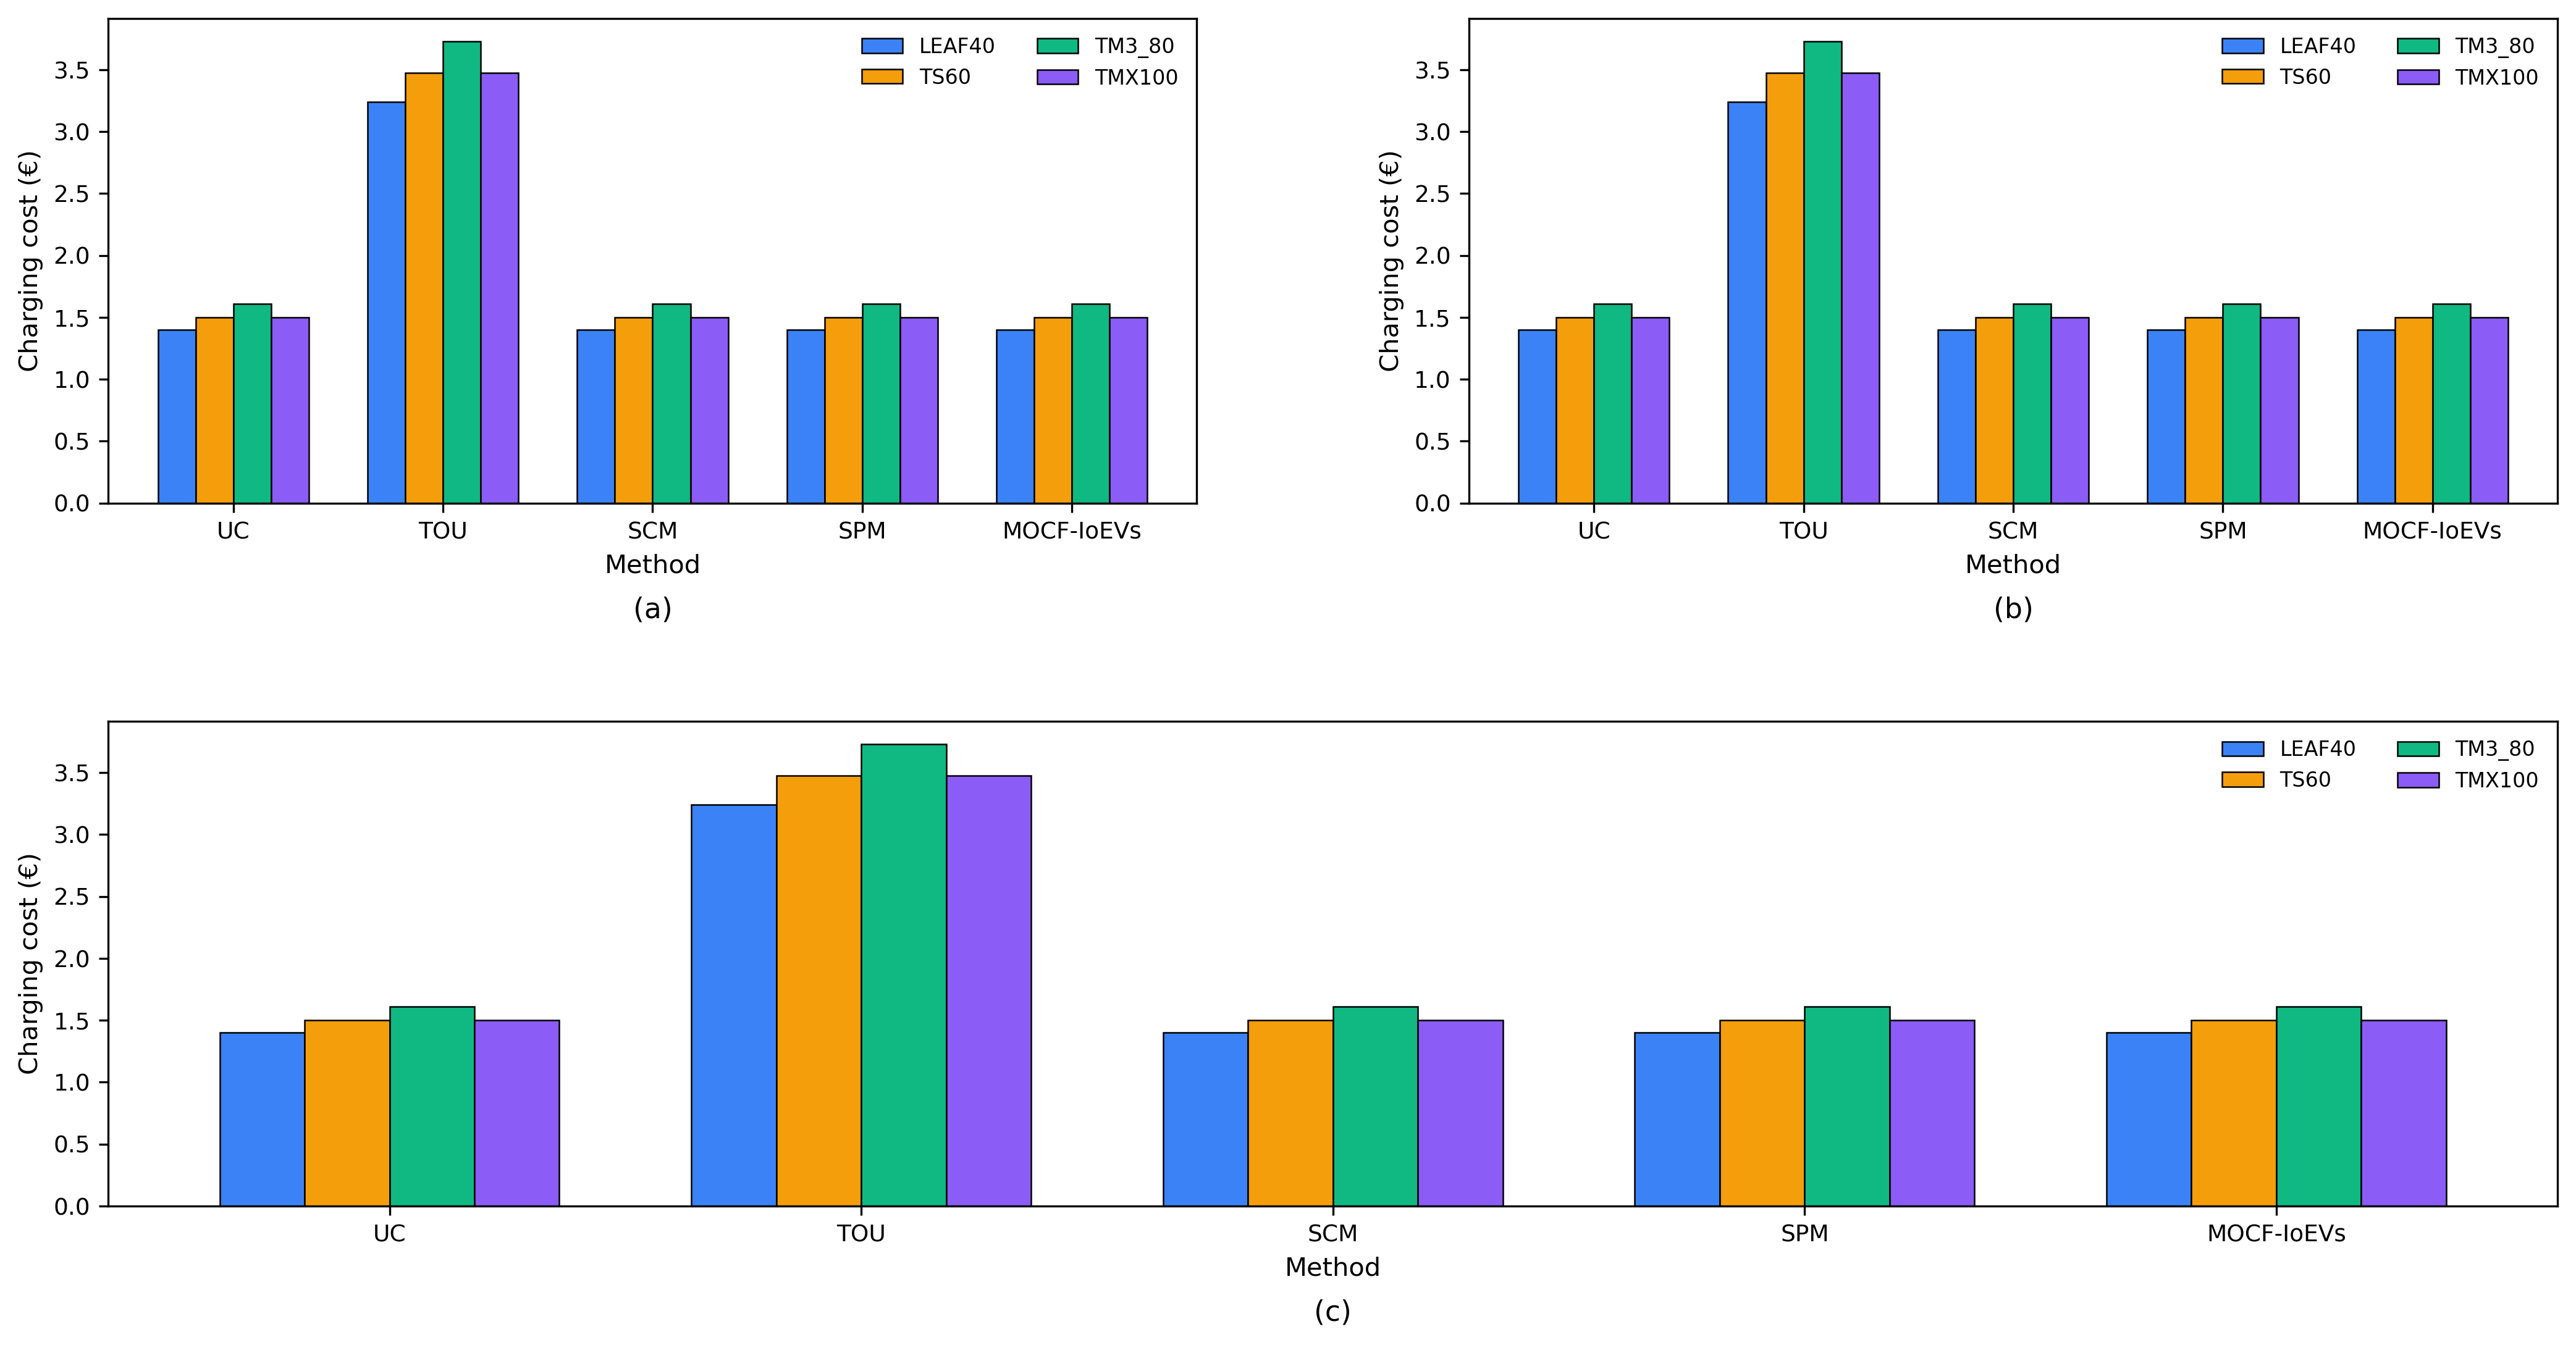

In [167]:
# ======================================================
# STEP 16: Plot charging cost comparison (clean, per-plot legend)
# ======================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

method_order = ["UC", "TOU", "SCM", "SPM", "MOCF-IoEVs"]
load_order = ["SMALL", "MEDIUM", "LARGE"]

plot_df = scenario_results_df.copy()
plot_df = plot_df[plot_df["MethodAbbr"].isin(method_order)].copy()
plot_df = plot_df[plot_df["LoadProfile"].isin(load_order)].copy()

plot_df["MethodAbbr"] = pd.Categorical(
    plot_df["MethodAbbr"],
    categories=method_order,
    ordered=True
)

scenario_order = [
    sc["EV_Abbr"]
    for sc in ev_scenarios
    if sc["EV_Abbr"] in plot_df["ScenarioAbbr"].unique()
]

# Colors for EV scenarios
colors = {
    "LEAF40": "#3B82F6",
    "TS60": "#F59E0B",
    "TM3_80": "#10B981",
    "TMX100": "#8B5CF6"
}

# Figure layout
fig = plt.figure(figsize=(14, 8), dpi=300)
gs = fig.add_gridspec(2, 2)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, :])
]

panel_labels = ["(a)", "(b)", "(c)"]

for idx, load_name in enumerate(load_order):
    ax = axes[idx]

    sub = plot_df[plot_df["LoadProfile"] == load_name].copy()

    pivot_df = sub.pivot_table(
        index="MethodAbbr",
        columns="ScenarioAbbr",
        values="ChargingCost",
        aggfunc="first"
    ).reindex(method_order)

    x = np.arange(len(method_order))
    n_scenarios = len(scenario_order)

    bar_width = min(0.18, 0.8 / max(n_scenarios, 1))

    for i, sc_abbr in enumerate(scenario_order):
        if sc_abbr not in pivot_df.columns:
            continue

        offset = (i - (n_scenarios - 1) / 2) * bar_width

        ax.bar(
            x + offset,
            pivot_df[sc_abbr].values,
            width=bar_width,
            color=colors.get(sc_abbr, "#777777"),
            edgecolor="black",
            linewidth=0.6,
            label=sc_abbr
        )

    ax.set_xlabel("Method", fontsize=10)
    ax.set_ylabel("Charging cost (€)", fontsize=10)

    ax.set_xticks(x)
    ax.set_xticklabels(method_order, fontsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(False)

    ax.legend(
        loc="upper right",
        frameon=False,
        fontsize=8,
        ncol=2
    )

    ax.text(
        0.5, -0.22, panel_labels[idx],
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=11
    )

plt.tight_layout()
plt.subplots_adjust(bottom=0.18, hspace=0.45, wspace=0.25)

save_path = os.path.join(COST_FOLDER, "cost_comparison_clean.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

#  print("STEP 16 completed successfully.")

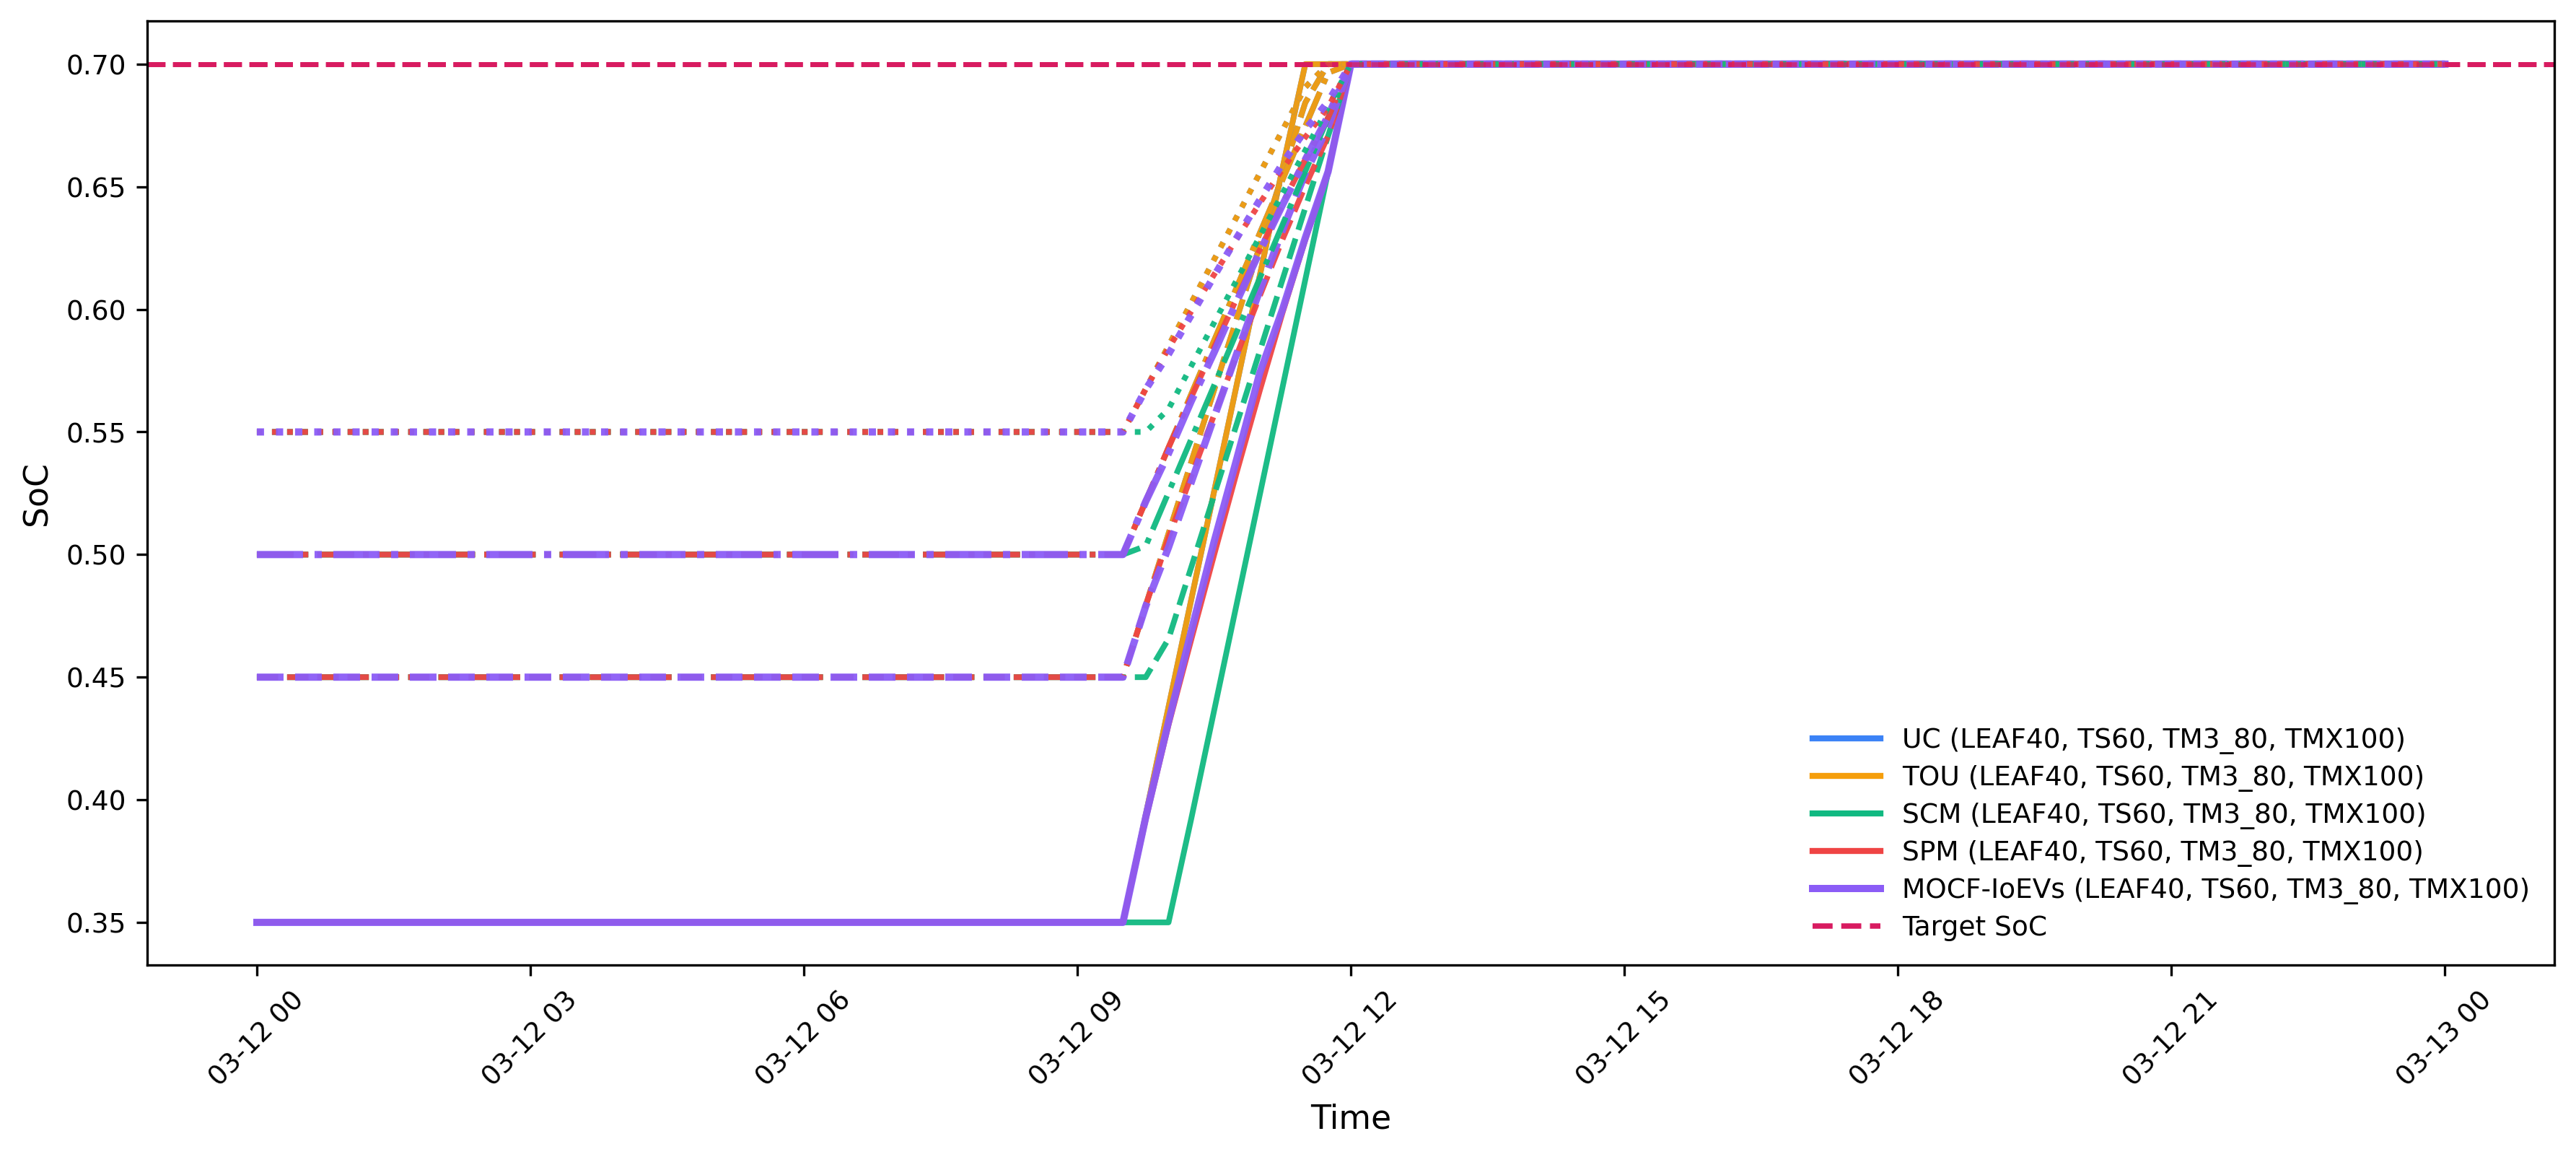

Saved: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Simulation_Results_MultiEV_MultiLoad/SoC_a.jpg


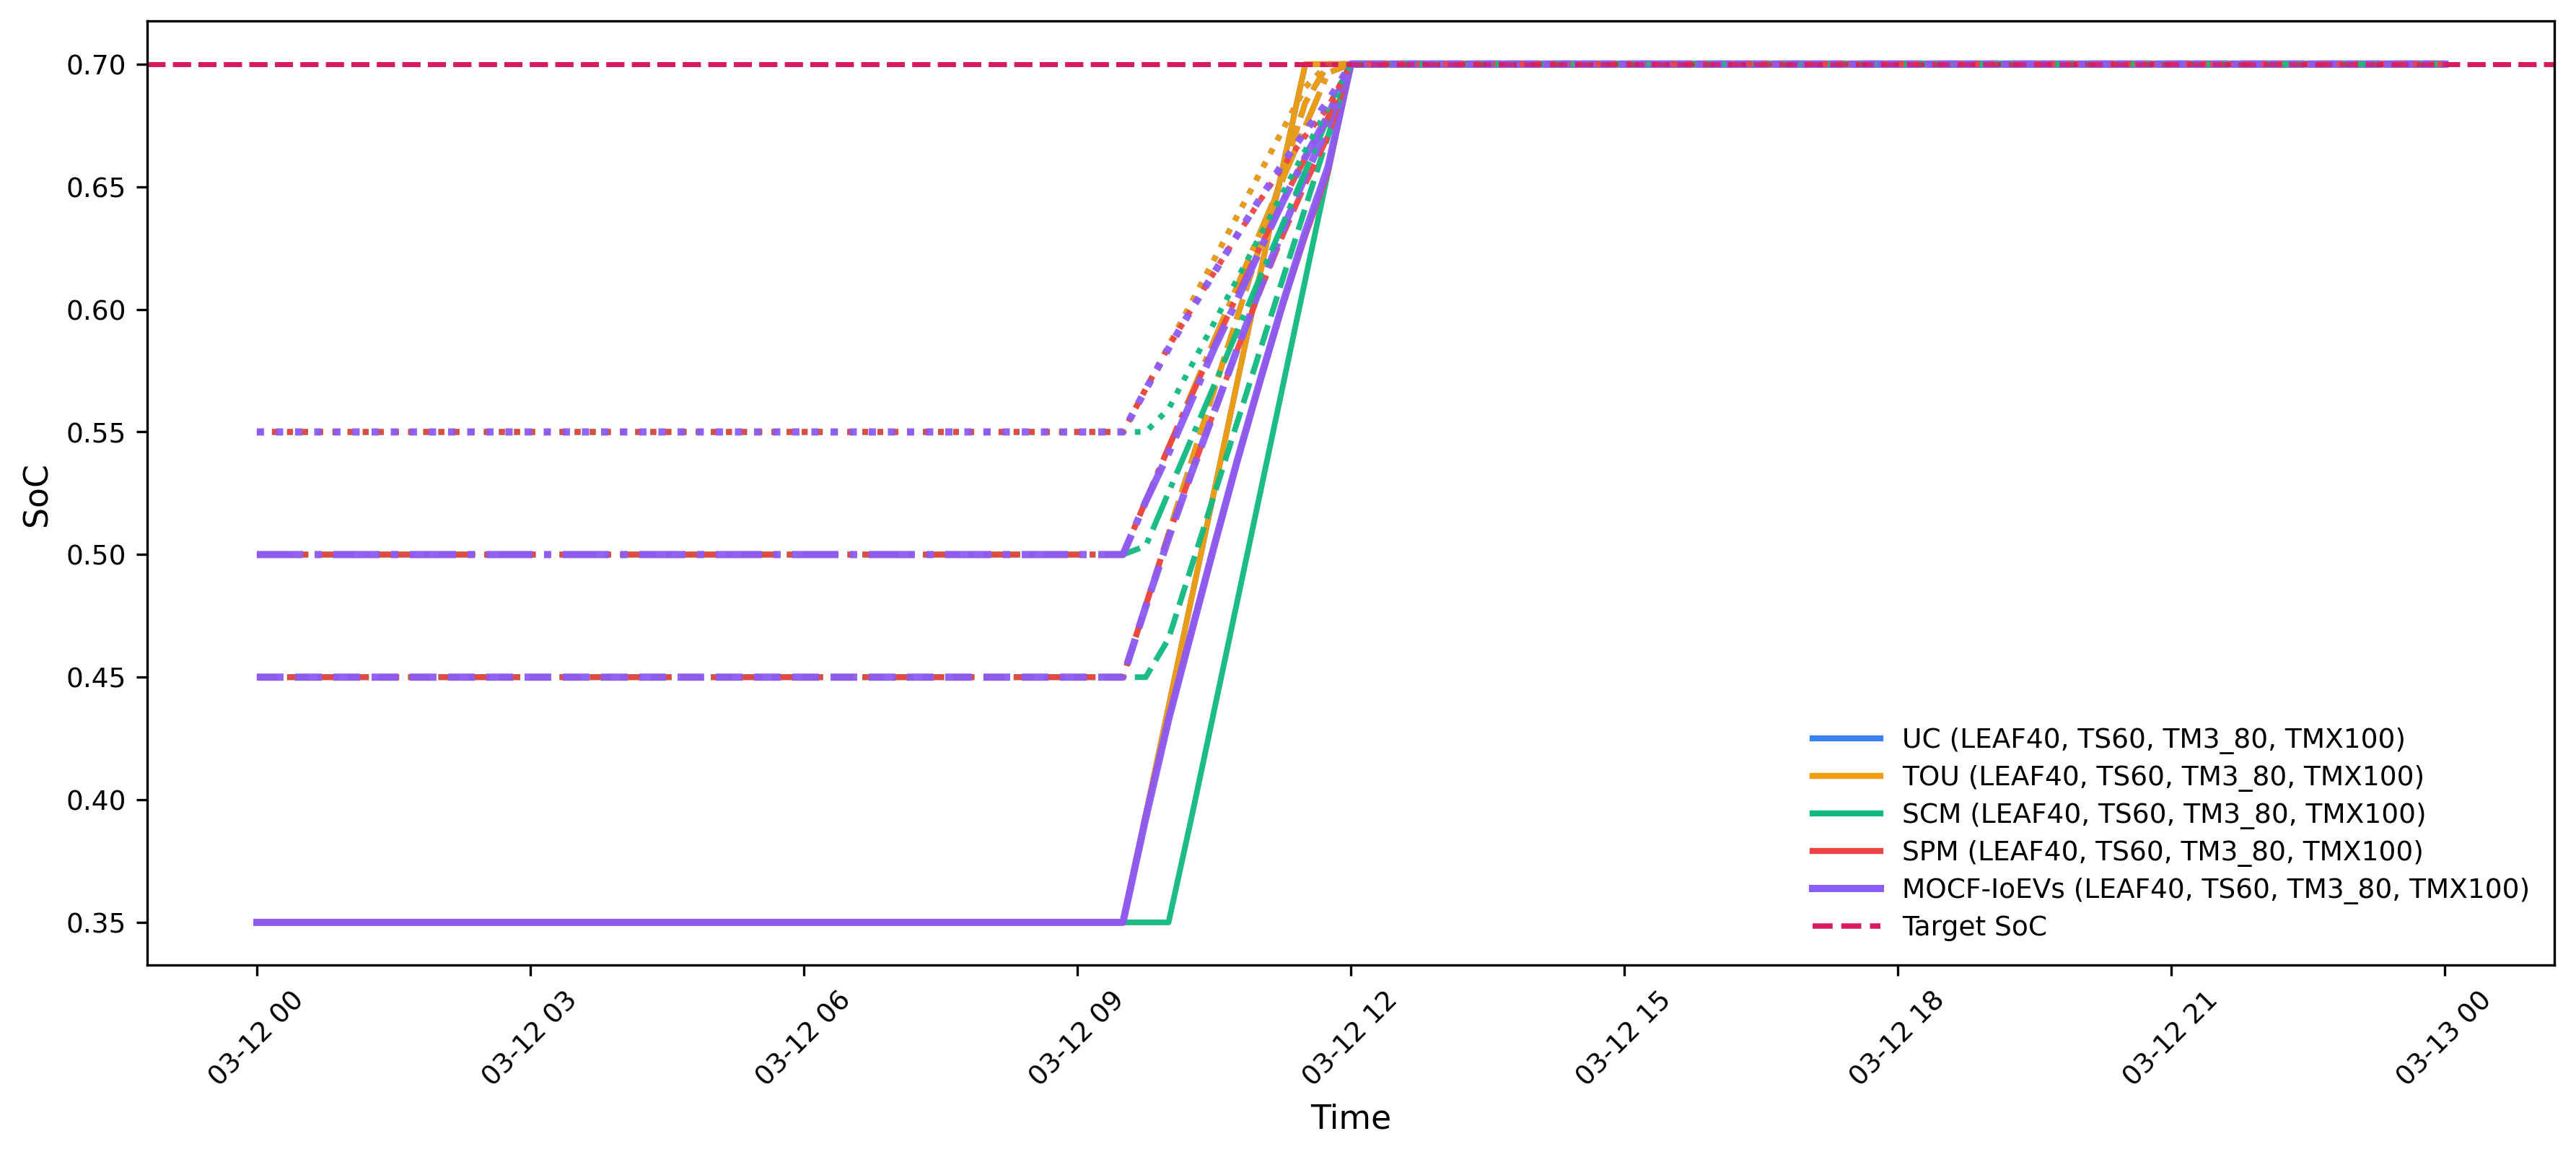

Saved: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Simulation_Results_MultiEV_MultiLoad/SoC_b.jpg


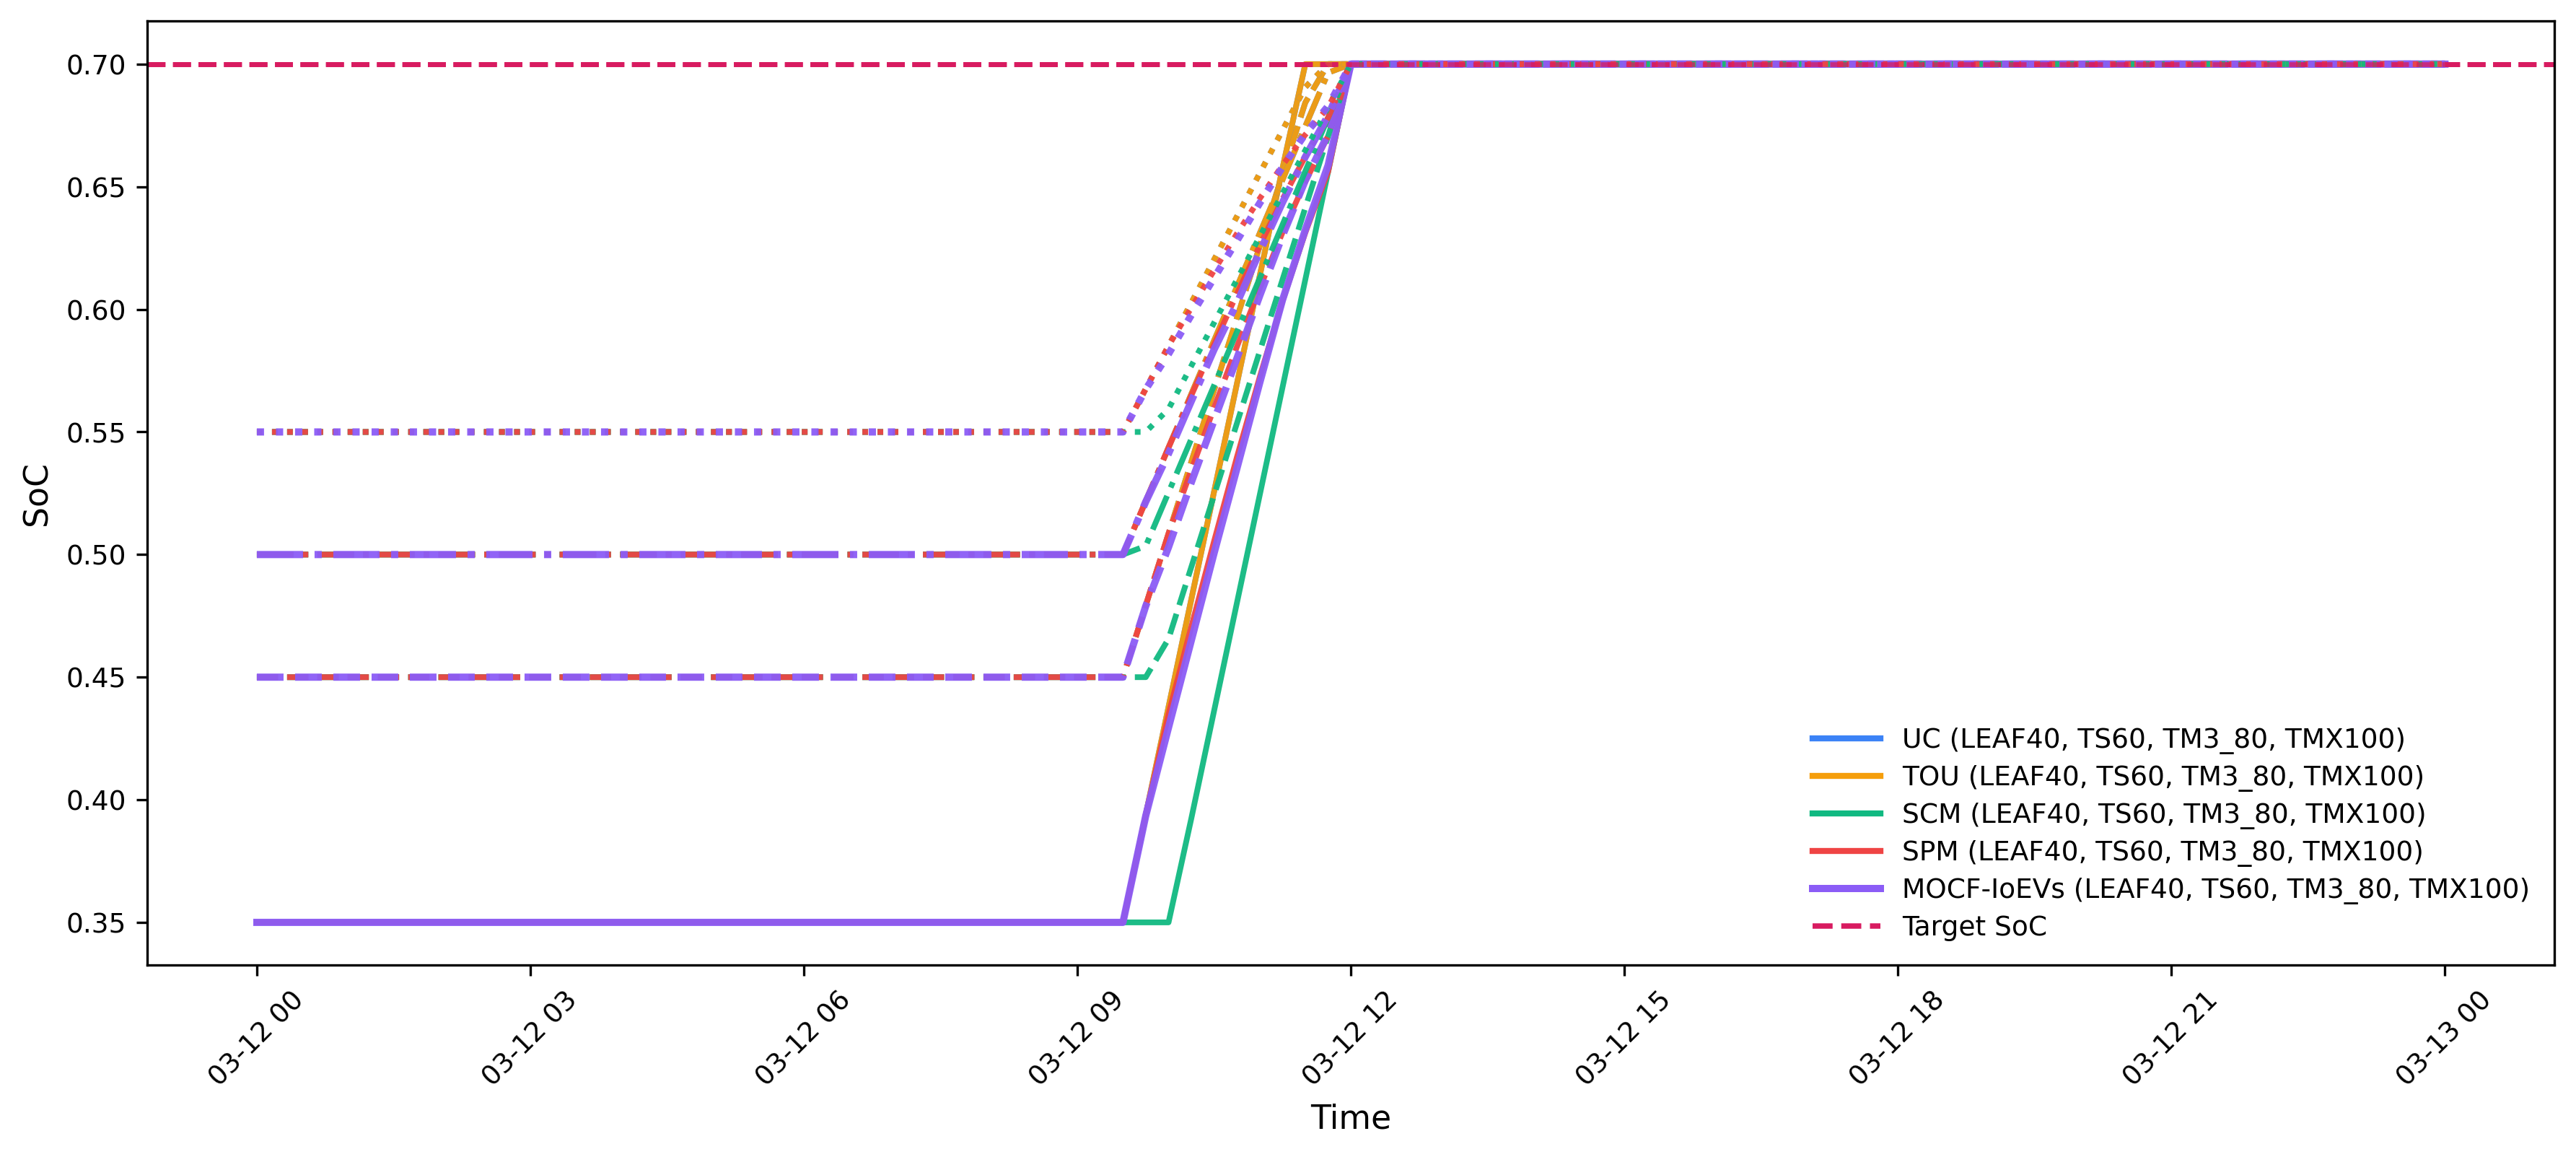

Saved: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Simulation_Results_MultiEV_MultiLoad/SoC_c.jpg


In [170]:
# ======================================================
# STEP 17: SoC trajectories (clean paper style)
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os

# ------------------------------------------------------
# Method / load order
# ------------------------------------------------------
method_order = ["UC", "TOU", "SCM", "SPM", "MOCF-IoEVs"]
load_order = ["SMALL", "MEDIUM", "LARGE"]
file_labels = {"SMALL": "a", "MEDIUM": "b", "LARGE": "c"}

# ------------------------------------------------------
# Colors for methods
# ------------------------------------------------------
method_colors = {
    "UC": "#3B82F6",
    "TOU": "#F59E0B",
    "SCM": "#10B981",
    "SPM": "#EF4444",
    "MOCF-IoEVs": "#8B5CF6"
}

# ------------------------------------------------------
# Line styles for EV types
# ------------------------------------------------------
ev_linestyles = {
    "LEAF40": "-",
    "TS60": "--",
    "TM3_80": "-.",
    "TMX100": ":"
}

# ------------------------------------------------------
# Target line color
# ------------------------------------------------------
target_color = "#D81B60"

# ------------------------------------------------------
# Fixed output folder
# ------------------------------------------------------
base_path = r"/Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Simulation_Results_MultiEV_MultiLoad"
os.makedirs(base_path, exist_ok=True)

# ------------------------------------------------------
# Loop over household loads
# ------------------------------------------------------
for load_name in load_order:

    fig, ax = plt.subplots(figsize=(12, 5.5), dpi=300)

    cases = [
        (ev_abbr, out)
        for (ld, ev_abbr), out in case_outputs.items()
        if ld == load_name
    ]

    ev_order_local = ["LEAF40", "TS60", "TM3_80", "TMX100"]
    cases = sorted(
        cases,
        key=lambda x: ev_order_local.index(x[0]) if x[0] in ev_order_local else 999
    )

    # --------------------------------------------------
    # Plot SoC curves
    # --------------------------------------------------
    for ev_abbr, out in cases:
        profiles = out["profiles"]
        battery_kwh = out["battery_kwh"]
        soc_init = out["soc_init"]
        soc_target = out["soc_target"]

        time_soc = list(df["time"].values) + [
            df["time"].values[-1] + np.timedelta64(15, "m")
        ]

        for method in method_order:
            if method not in profiles:
                continue

            soc = simulate_soc(profiles[method], soc_init, battery_kwh)

            ax.plot(
                time_soc,
                soc,
                color=method_colors[method],
                linestyle=ev_linestyles.get(ev_abbr, "-"),
                linewidth=2.4 if method == "MOCF-IoEVs" else 1.9,
                alpha=0.95
            )

        ax.axhline(
            soc_target,
            color=target_color,
            linestyle="--",
            linewidth=1.6,
            alpha=0.75
        )

    # --------------------------------------------------
    # Axis formatting
    # --------------------------------------------------
    ax.set_xlabel("Time", fontsize=11)
    ax.set_ylabel("SoC", fontsize=11)
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(False)

    # --------------------------------------------------
    # Legend
    # --------------------------------------------------
    legend_handles = []

    for method in method_order:
        legend_handles.append(
            Line2D(
                [0], [0],
                color=method_colors[method],
                lw=2.4 if method == "MOCF-IoEVs" else 2.0,
                linestyle="-",
                label=f"{method} (LEAF40, TS60, TM3_80, TMX100)"
            )
        )

    legend_handles.append(
        Line2D(
            [0], [0],
            color=target_color,
            lw=1.8,
            linestyle="--",
            label="Target SoC"
        )
    )

    ax.legend(
        handles=legend_handles,
        loc="lower right",
        frameon=False,
        fontsize=9,
        handlelength=2.5,
        labelspacing=0.4
    )

    # --------------------------------------------------
    # Layout and save
    # --------------------------------------------------
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18)

    file_name = f"SoC_{file_labels[load_name]}.jpg"
    save_path = os.path.join(base_path, file_name)

    plt.savefig(save_path, dpi=300, bbox_inches="tight", format="jpg")

    plt.show()
    print(f"Saved: {save_path}")

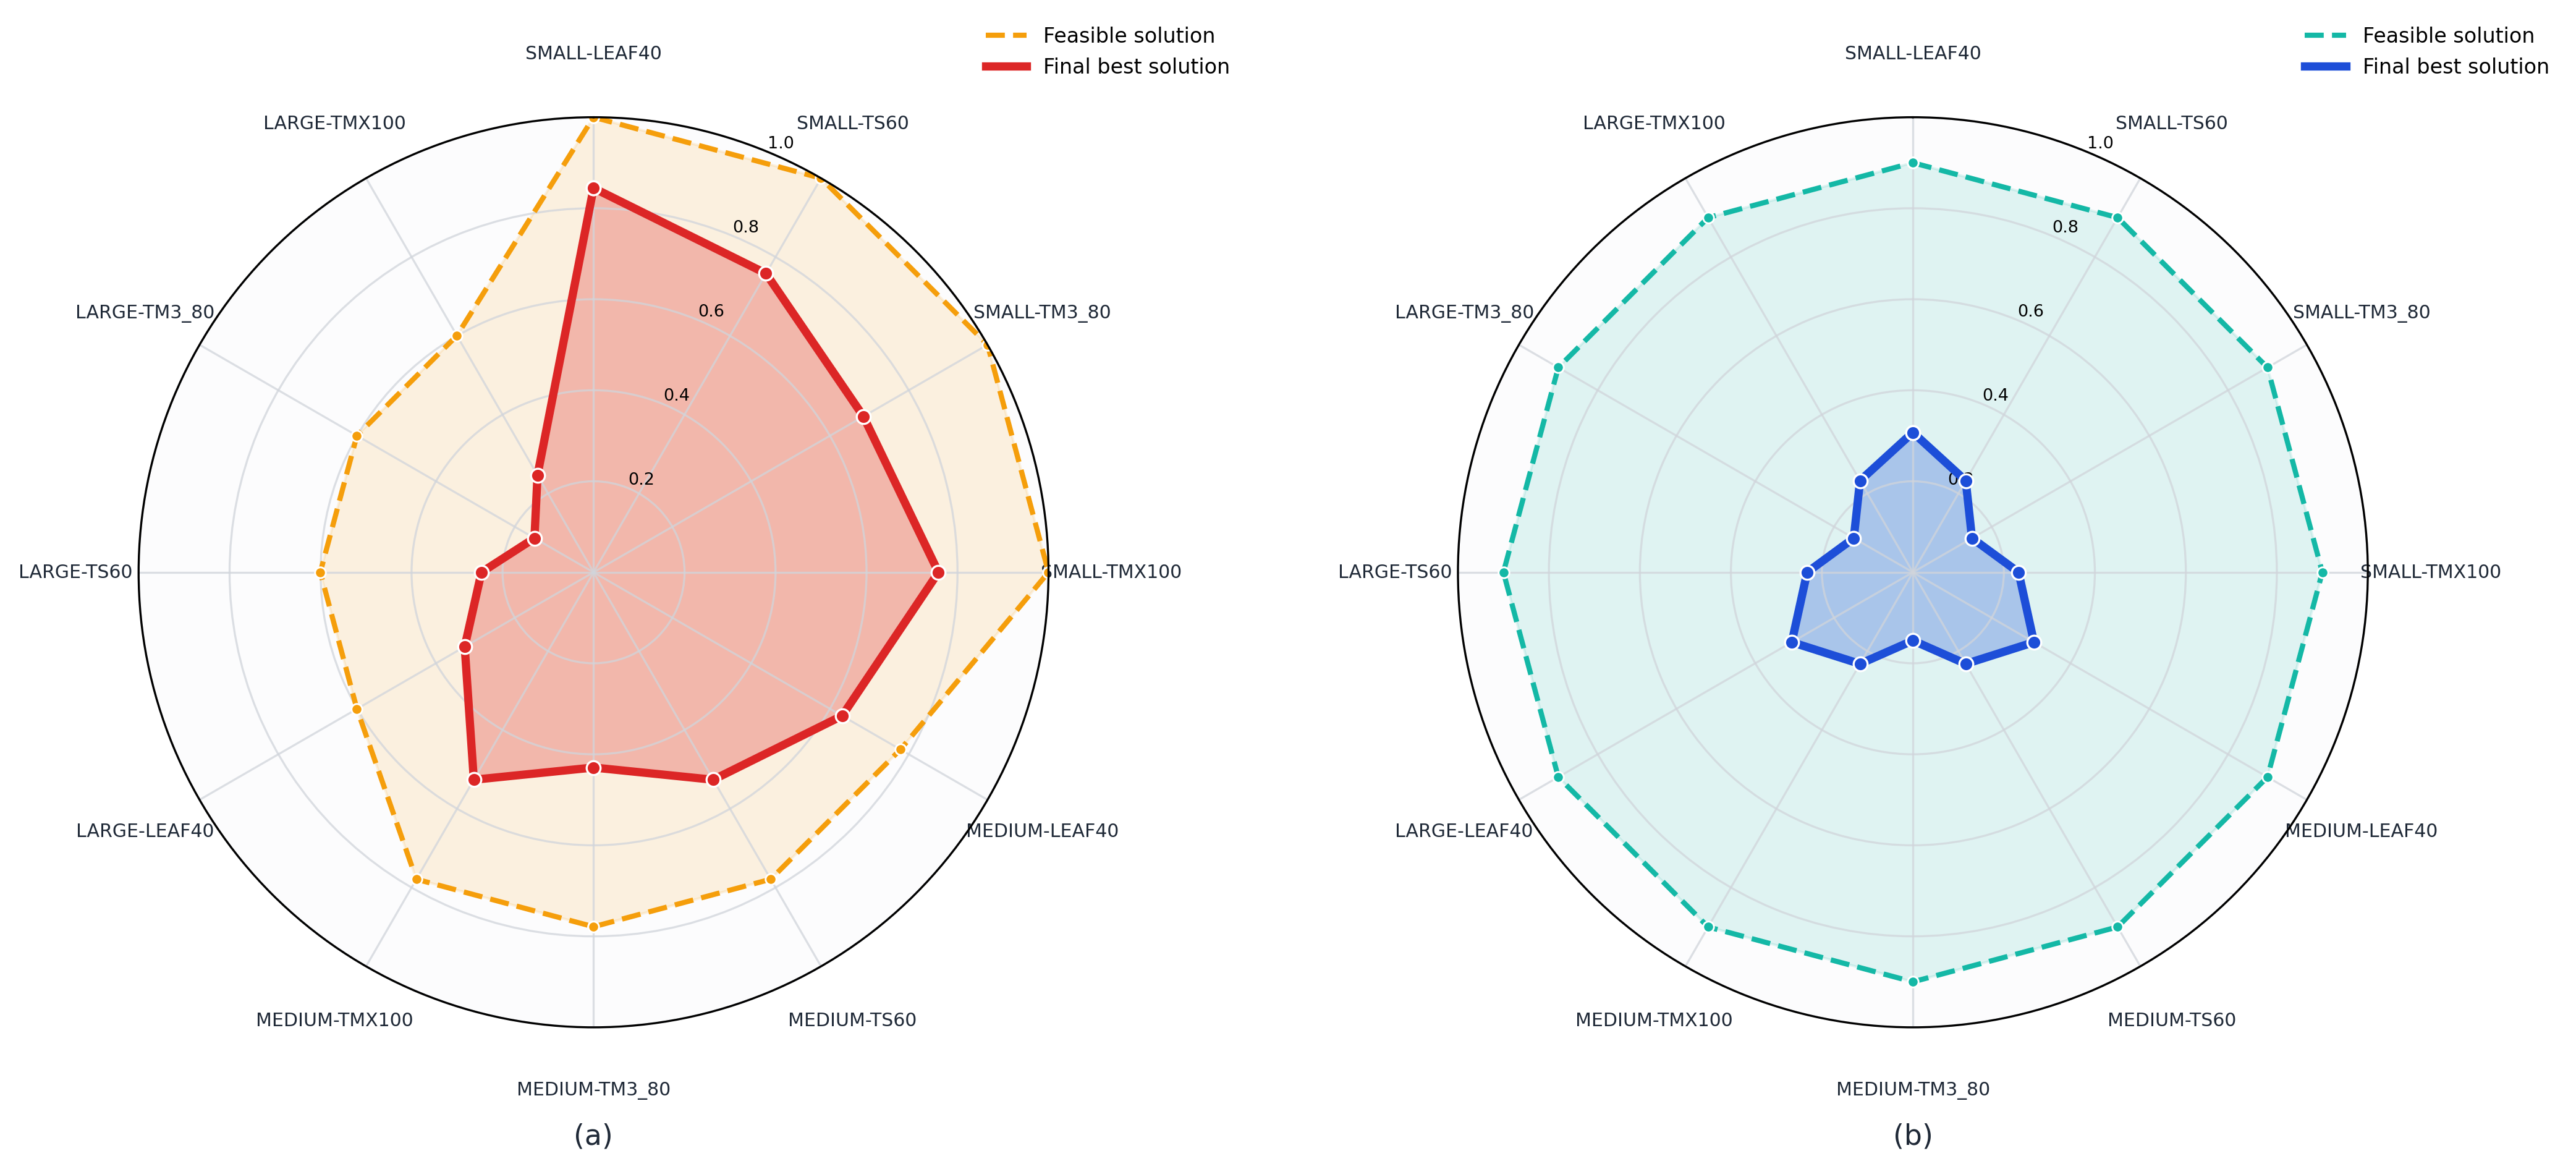

STEP 18 completed successfully.


In [160]:
# ======================================================
# STEP 18: Convergence of proposed MOCF-IoEVs
# (a) Peak load: feasible vs final best
# (b) Charging cost: feasible vs final best
# Improved readability with visible inner radius floor
# ======================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -----------------------------
# Choose generation for feasible/reference solution
# -----------------------------
feasible_gen_index = 0

# -----------------------------
# Prepare data
# -----------------------------
labels = []
cost_feasible = []
cost_final = []
peak_feasible = []
peak_final = []

case_order_load = {"SMALL": 0, "MEDIUM": 1, "LARGE": 2}
case_order_ev = {"LEAF40": 0, "TS60": 1, "TM3_80": 2, "TMX100": 3}

sorted_cases = sorted(
    case_outputs.items(),
    key=lambda x: (
        case_order_load.get(x[0][0], 999),
        case_order_ev.get(x[0][1], 999)
    )
)

if len(sorted_cases) == 0:
    raise ValueError("case_outputs is empty. Please run the previous steps first.")

for (load_name, ev_abbr), out in sorted_cases:
    labels.append(f"{load_name}-{ev_abbr}")

    hist_cost = np.array(out["hist_cost"], dtype=float)
    hist_peak = np.array(out["hist_peak"], dtype=float)

    if len(hist_cost) == 0 or len(hist_peak) == 0:
        raise ValueError(f"Empty optimization history found for case: {load_name}-{ev_abbr}")

    g_idx = min(feasible_gen_index, len(hist_cost) - 1)

    cost_feasible.append(hist_cost[g_idx])
    cost_final.append(hist_cost[-1])

    peak_feasible.append(hist_peak[g_idx])
    peak_final.append(hist_peak[-1])

cost_feasible = np.array(cost_feasible, dtype=float)
cost_final = np.array(cost_final, dtype=float)
peak_feasible = np.array(peak_feasible, dtype=float)
peak_final = np.array(peak_final, dtype=float)

# -----------------------------
# Normalize and invert
# -----------------------------
def normalize_invert(feasible_vals, final_vals):
    all_vals = np.concatenate([feasible_vals, final_vals])
    vmin, vmax = all_vals.min(), all_vals.max()

    feasible_norm = (feasible_vals - vmin) / (vmax - vmin + 1e-12)
    final_norm = (final_vals - vmin) / (vmax - vmin + 1e-12)

    return 1.0 - feasible_norm, 1.0 - final_norm

cost_feasible_norm, cost_final_norm = normalize_invert(cost_feasible, cost_final)
peak_feasible_norm, peak_final_norm = normalize_invert(peak_feasible, peak_final)

# -----------------------------
# Add radius floor
# -----------------------------
def apply_radius_floor(values, floor=0.15):
    return floor + (1.0 - floor) * values

cost_feasible_plot = apply_radius_floor(cost_feasible_norm)
cost_final_plot = apply_radius_floor(cost_final_norm)

peak_feasible_plot = apply_radius_floor(peak_feasible_norm)
peak_final_plot = apply_radius_floor(peak_final_norm)

# -----------------------------
# Reduce feasible cost region slightly
# -----------------------------
cost_feasible_plot = 0.90 * cost_feasible_plot

# -----------------------------
# Radar setup
# -----------------------------
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles_closed = angles + [angles[0]]

def close(vals):
    return np.concatenate([vals, [vals[0]]])

cost_feasible_closed = close(cost_feasible_plot)
cost_final_closed = close(cost_final_plot)

peak_feasible_closed = close(peak_feasible_plot)
peak_final_closed = close(peak_final_plot)

# -----------------------------
# Figure
# -----------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 7),
    dpi=300,
    subplot_kw={"projection": "polar"}
)

fig.patch.set_facecolor("white")

peak_feasible_color = "#F59E0B"
peak_best_color = "#DC2626"

cost_feasible_color = "#14B8A6"
cost_best_color = "#1D4ED8"

grid_color = "#D1D5DB"
label_color = "#1F2937"
bg_color = "#FCFCFD"

# -----------------------------
# Helper function
# -----------------------------
def draw_radar(ax, labels, angles, angles_closed, feasible_vals, final_vals,
               feasible_color, final_color, panel_label):

    ax.set_facecolor(bg_color)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # Feasible
    ax.plot(
        angles_closed, feasible_vals,
        color=feasible_color, linewidth=2.0, linestyle="--",
        marker="o", markersize=4.2,
        markerfacecolor=feasible_color,
        markeredgecolor="white",
        markeredgewidth=0.7
    )

    ax.fill(
        angles_closed, feasible_vals,
        color=feasible_color, alpha=0.12
    )

    # Final best
    ax.plot(
        angles_closed, final_vals,
        color=final_color, linewidth=3.2, linestyle="-",
        marker="o", markersize=5.4,
        markerfacecolor=final_color,
        markeredgecolor="white",
        markeredgewidth=0.8
    )

    ax.fill(
        angles_closed, final_vals,
        color=final_color, alpha=0.28
    )

    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=7.2, color=label_color)
    ax.tick_params(axis="x", pad=14)

    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=6.5)

    ax.grid(color=grid_color, linewidth=0.8, alpha=0.75)

    legend_handles = [
        Line2D([0], [0], color=feasible_color, lw=2.0, linestyle="--", label="Feasible solution"),
        Line2D([0], [0], color=final_color, lw=3.2, linestyle="-", label="Final best solution"),
    ]

    ax.legend(
        handles=legend_handles,
        loc="upper right",
        bbox_to_anchor=(1.22, 1.12),
        frameon=False,
        fontsize=8
    )

    ax.text(
        0.5, -0.12, panel_label,
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=11,
        color=label_color
    )

# -----------------------------
# (a) Peak
# -----------------------------
draw_radar(
    axes[0],
    labels, angles, angles_closed,
    peak_feasible_closed, peak_final_closed,
    peak_feasible_color, peak_best_color,
    "(a)"
)

# -----------------------------
# (b) Cost
# -----------------------------
draw_radar(
    axes[1],
    labels, angles, angles_closed,
    cost_feasible_closed, cost_final_closed,
    cost_feasible_color, cost_best_color,
    "(b)"
)

# -----------------------------
# Layout
# -----------------------------
plt.tight_layout()
plt.subplots_adjust(wspace=0.45, bottom=0.16)

save_path = os.path.join(CONV_FOLDER, "radar_feasible_vs_best_visible.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("STEP 18 completed successfully.")

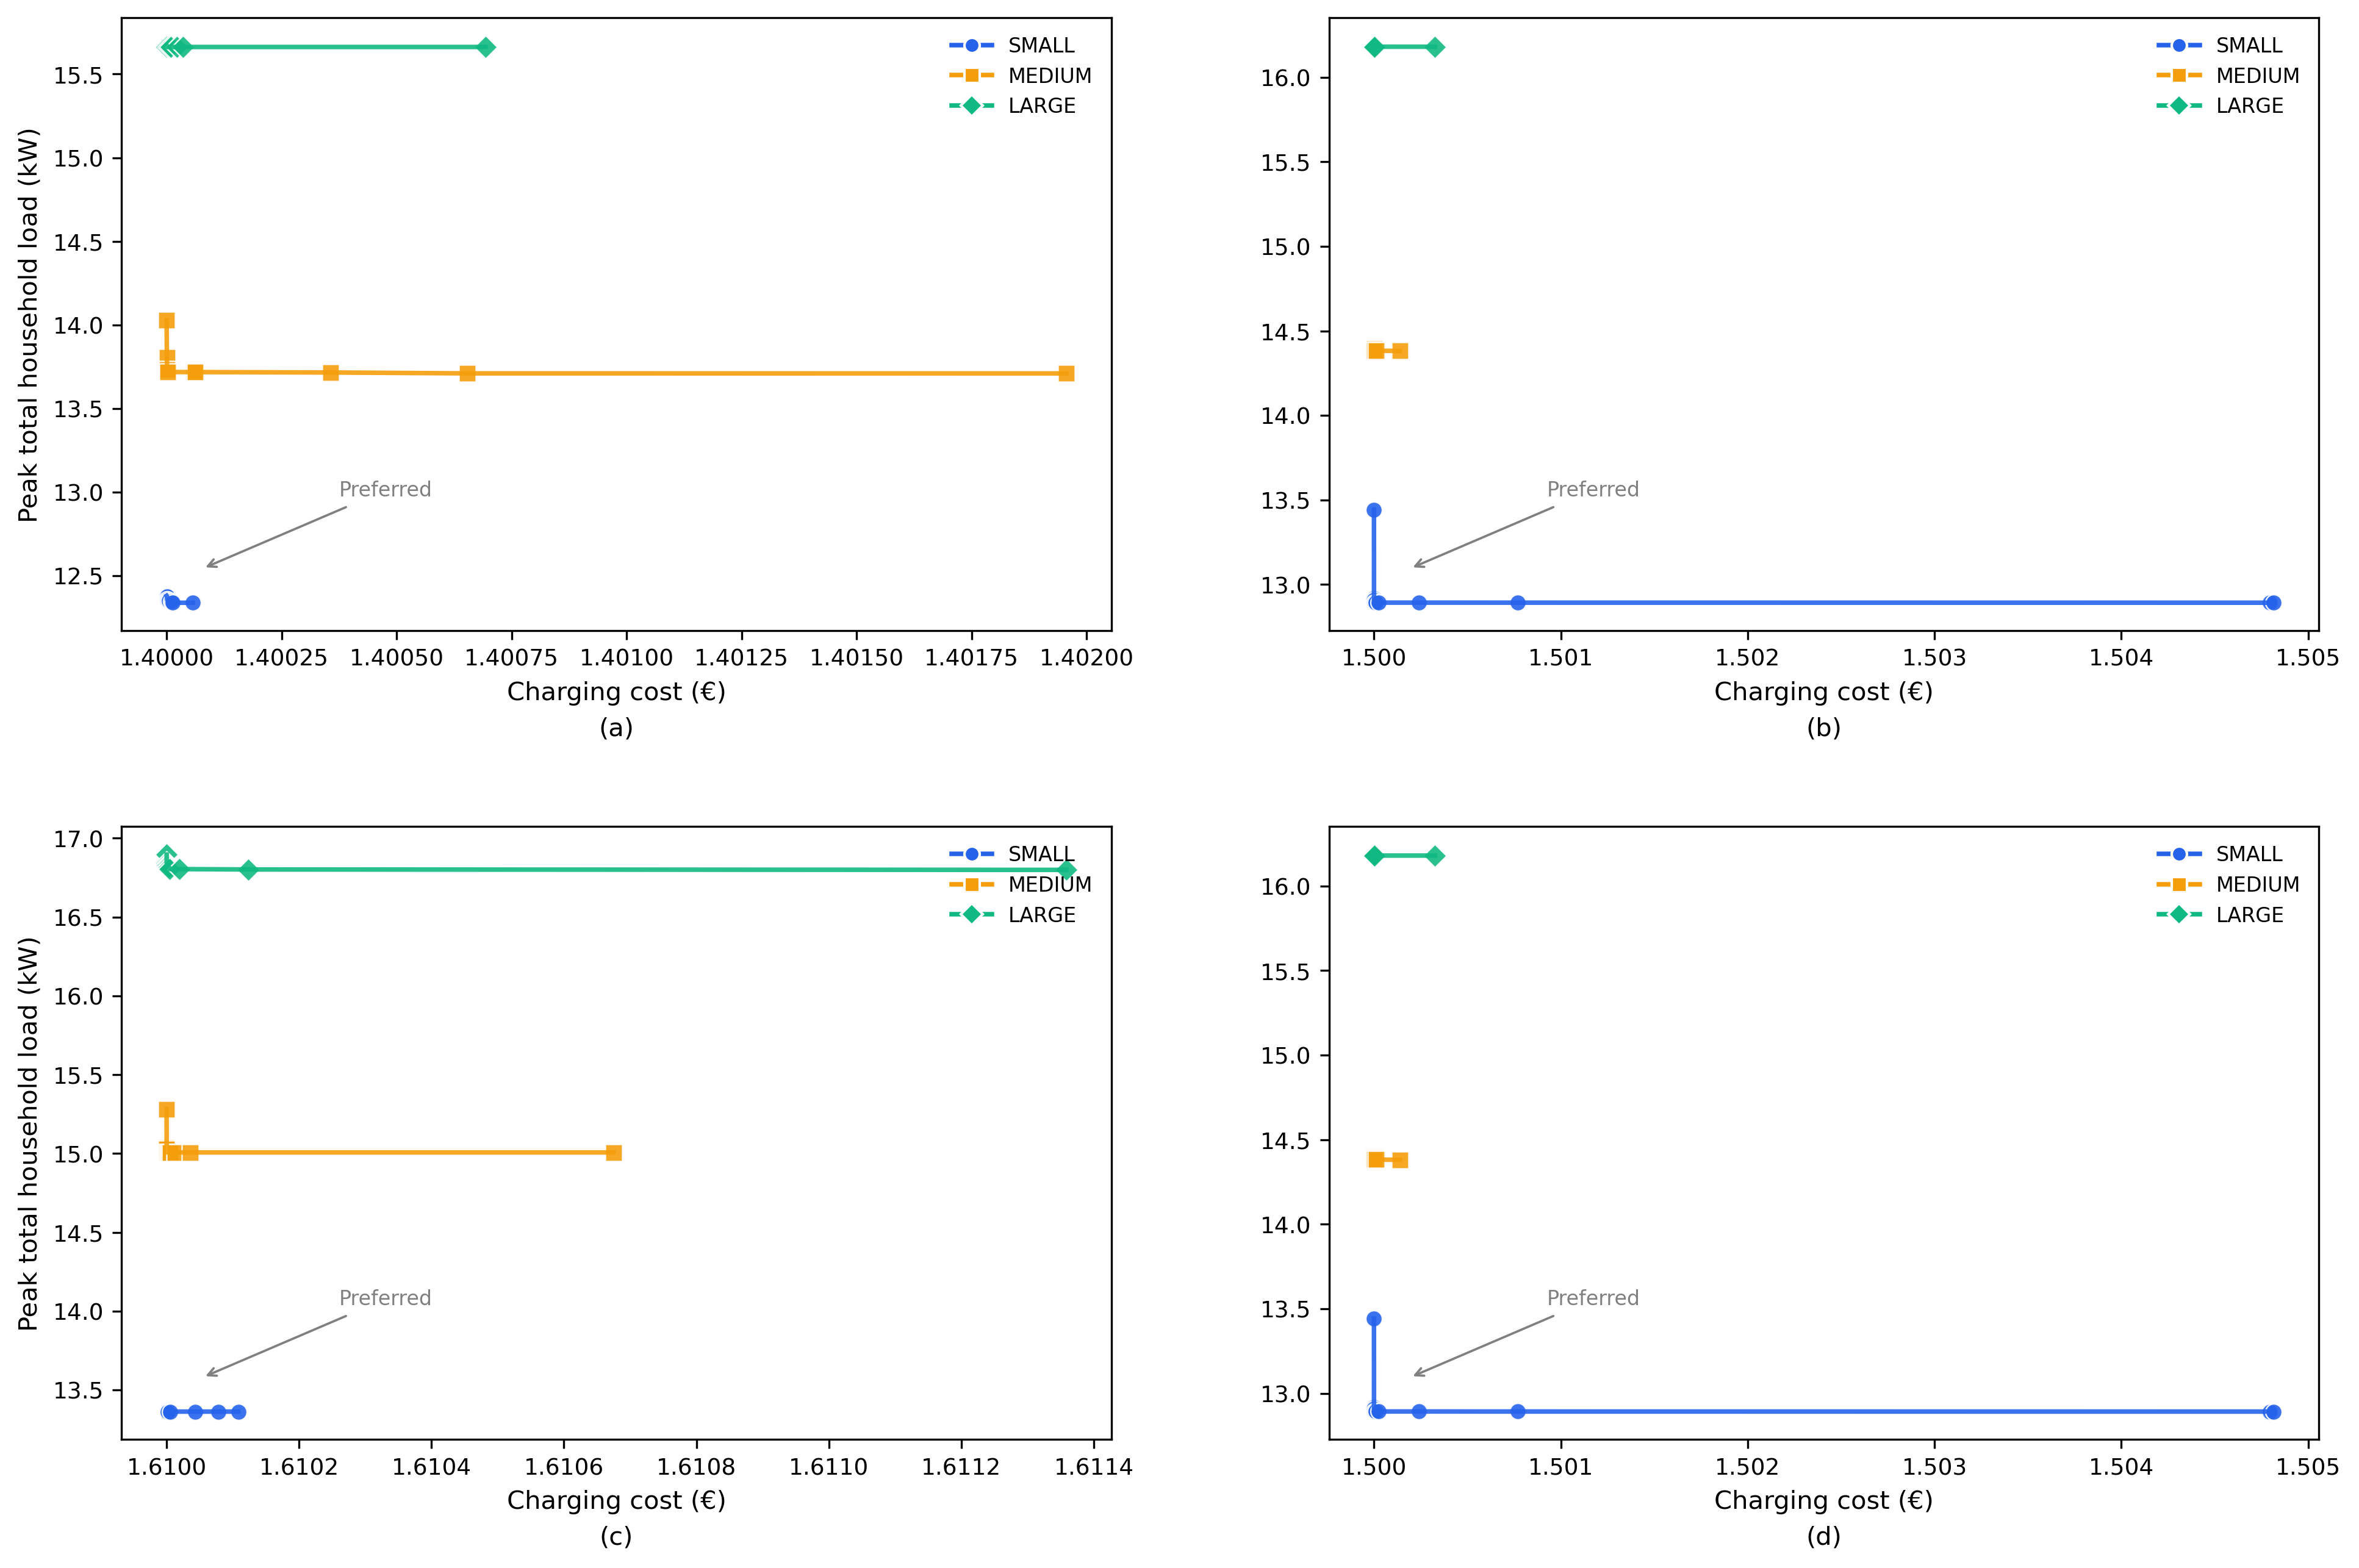

STEP 19 completed successfully.


In [161]:
# ======================================================
# STEP 19: Pareto fronts, clean version
# One subplot per EV, 2x2 layout
# EV names removed from inside plots
# ======================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ev_order = ["LEAF40", "TS60", "TM3_80", "TMX100"]
load_order = ["SMALL", "MEDIUM", "LARGE"]
panel_labels = ["(a)", "(b)", "(c)", "(d)"]

# Clear colors
load_colors = {
    "SMALL": "#2563EB",
    "MEDIUM": "#F59E0B",
    "LARGE": "#10B981"
}

# Distinct markers
load_markers = {
    "SMALL": "o",
    "MEDIUM": "s",
    "LARGE": "D"
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9), dpi=300)
axes = axes.flatten()

for idx, ev_abbr in enumerate(ev_order):
    ax = axes[idx]
    found_loads = []

    for load_name in load_order:
        key = (load_name, ev_abbr)

        if key not in case_outputs:
            continue

        F = case_outputs[key].get("pareto_F", None)

        if F is None or len(F) == 0:
            continue

        F = np.asarray(F, dtype=float)
        F_sorted = F[np.argsort(F[:, 0])]

        found_loads.append(load_name)

        # Pareto frontier line
        ax.plot(
            F_sorted[:, 0],
            F_sorted[:, 1],
            color=load_colors[load_name],
            linewidth=1.8,
            alpha=0.9
        )

        # Pareto points
        ax.scatter(
            F_sorted[:, 0],
            F_sorted[:, 1],
            s=42,
            color=load_colors[load_name],
            marker=load_markers[load_name],
            edgecolors="white",
            linewidths=0.6,
            alpha=0.9
        )

    # Axis labels
    ax.set_xlabel("Charging cost (€)", fontsize=10)
    if idx in [0, 2]:
        ax.set_ylabel("Peak total household load (kW)", fontsize=10)

    ax.tick_params(axis="both", labelsize=9)
    ax.grid(False)

    # Preferred direction annotation
    ax.annotate(
        "Preferred",
        xy=(0.08, 0.10),
        xytext=(0.22, 0.22),
        textcoords="axes fraction",
        xycoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=0.9, color="gray"),
        fontsize=8,
        color="gray"
    )

    # Legend
    if found_loads:
        legend_handles = [
            Line2D(
                [0], [0],
                color=load_colors[ld],
                marker=load_markers[ld],
                lw=1.8,
                markersize=6,
                markerfacecolor=load_colors[ld],
                markeredgecolor="white",
                label=ld
            )
            for ld in found_loads
        ]

        ax.legend(
            handles=legend_handles,
            loc="upper right",
            frameon=False,
            fontsize=8
        )

    # Panel label
    ax.text(
        0.5, -0.16,
        panel_labels[idx],
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.subplots_adjust(bottom=0.12, hspace=0.32, wspace=0.22)

save_path = os.path.join(PARETO_FOLDER, "pareto_fronts_clean.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("STEP 19 completed successfully.")

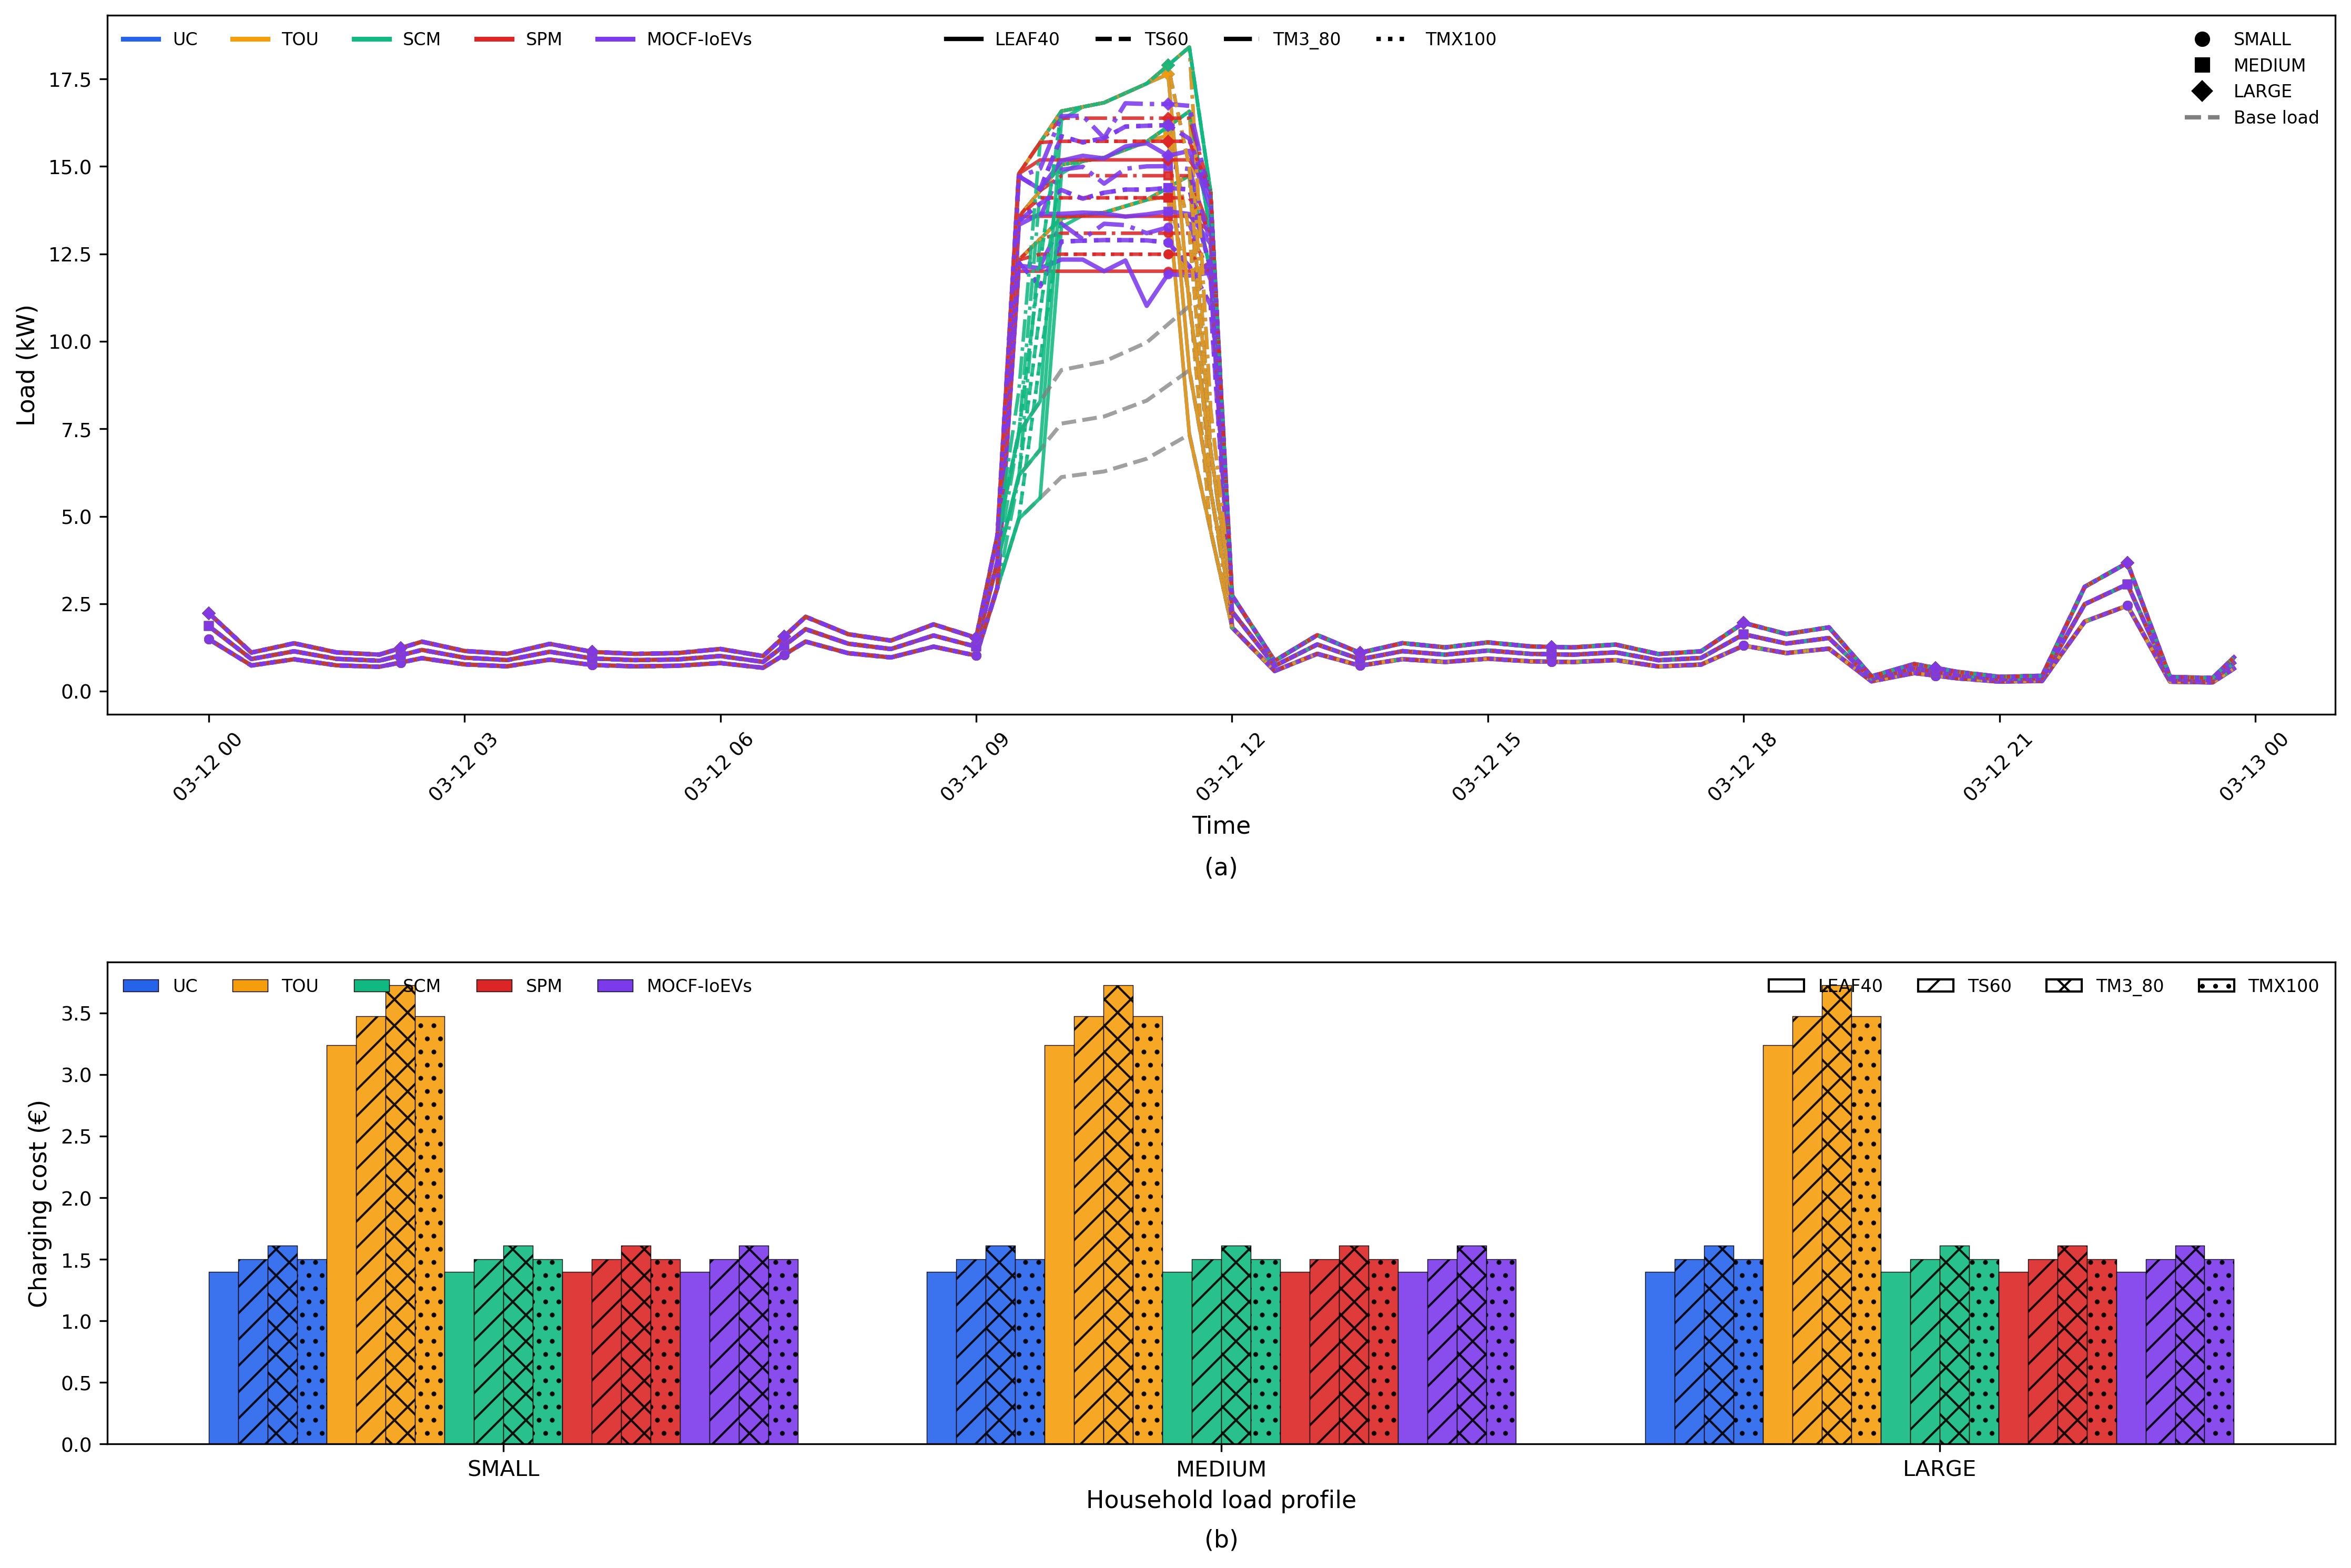

STEP 20 completed successfully.


In [162]:
# ======================================================
# STEP 20: Final combined figure
# - Top = one overall load plot including methods, EVs, and house types
# - Bottom = grouped bar chart of charging cost
# - Each plot has its own legends
# ======================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

method_order = ["UC", "TOU", "SCM", "SPM", "MOCF-IoEVs"]
ev_order = ["LEAF40", "TS60", "TM3_80", "TMX100"]
load_order = ["SMALL", "MEDIUM", "LARGE"]

# ------------------------------------------------------
# Colors for methods
# ------------------------------------------------------
method_colors = {
    "UC": "#2563EB",
    "TOU": "#F59E0B",
    "SCM": "#10B981",
    "SPM": "#DC2626",
    "MOCF-IoEVs": "#7C3AED"
}

# ------------------------------------------------------
# Line styles for EVs
# ------------------------------------------------------
ev_linestyles = {
    "LEAF40": "-",
    "TS60": "--",
    "TM3_80": "-.",
    "TMX100": ":"
}

# ------------------------------------------------------
# Markers for house types
# ------------------------------------------------------
load_markers = {
    "SMALL": "o",
    "MEDIUM": "s",
    "LARGE": "D"
}

# ------------------------------------------------------
# Hatches for EVs in bar chart
# ------------------------------------------------------
ev_hatches = {
    "LEAF40": "",
    "TS60": "//",
    "TM3_80": "xx",
    "TMX100": ".."
}

# ------------------------------------------------------
# Build cost table for all methods
# ------------------------------------------------------
plot_df = scenario_results_df.copy()
plot_df = plot_df[plot_df["MethodAbbr"].isin(method_order)].copy()
plot_df = plot_df[plot_df["ScenarioAbbr"].isin(ev_order)].copy()
plot_df = plot_df[plot_df["LoadProfile"].isin(load_order)].copy()

cost_pivot = plot_df.pivot_table(
    index=["MethodAbbr", "ScenarioAbbr"],
    columns="LoadProfile",
    values="ChargingCost",
    aggfunc="mean"
).reindex(
    index=pd.MultiIndex.from_product(
        [method_order, ev_order],
        names=["MethodAbbr", "ScenarioAbbr"]
    ),
    columns=load_order
)

# ------------------------------------------------------
# Figure layout
# ------------------------------------------------------
fig, (ax_top, ax_bar) = plt.subplots(
    2, 1,
    figsize=(15, 10),
    dpi=300,
    gridspec_kw={"height_ratios": [1.45, 1.0]}
)

# ------------------------------------------------------
# Top panel: one overall load plot
# color = method, linestyle = EV, marker = house type
# ------------------------------------------------------
for load_name in load_order:
    for ev_abbr in ev_order:
        key = (load_name, ev_abbr)

        if key not in case_outputs:
            continue

        out = case_outputs[key]
        house_kw = np.asarray(out["house_kw"])
        profiles = out["profiles"]

        # Base household load, plotted once per house type
        if ev_abbr == ev_order[0]:
            ax_top.plot(
                df["time"],
                house_kw,
                color="gray",
                linestyle="--",
                linewidth=1.8,
                alpha=0.75
            )

        for method in method_order:
            if method not in profiles:
                continue

            ax_top.plot(
                df["time"],
                house_kw + np.asarray(profiles[method]),
                color=method_colors[method],
                linestyle=ev_linestyles[ev_abbr],
                linewidth=1.6 if method != "MOCF-IoEVs" else 2.0,
                marker=load_markers[load_name],
                markevery=max(1, len(df) // 10),
                markersize=3.5,
                alpha=0.88
            )

ax_top.set_ylabel("Load (kW)", fontsize=11)
ax_top.set_xlabel("Time", fontsize=11)
ax_top.tick_params(axis="x", rotation=45, labelsize=9)
ax_top.tick_params(axis="y", labelsize=9)
ax_top.grid(False)

# Top plot legends
method_handles = [
    Line2D([0], [0], color=method_colors[m], lw=2.2, label=m)
    for m in method_order
]

ev_handles = [
    Line2D([0], [0], color="black", lw=2.0, linestyle=ev_linestyles[ev], label=ev)
    for ev in ev_order
]

load_handles = [
    Line2D([0], [0], color="black", marker=load_markers[ld], lw=0, markersize=6, label=ld)
    for ld in load_order
]

base_handle = [
    Line2D([0], [0], color="gray", lw=2.0, linestyle="--", label="Base load")
]

leg_top_1 = ax_top.legend(
    handles=method_handles,
    loc="upper left",
    frameon=False,
    fontsize=8,
    ncol=5
)
ax_top.add_artist(leg_top_1)

leg_top_2 = ax_top.legend(
    handles=ev_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.0),
    frameon=False,
    fontsize=8,
    ncol=4
)
ax_top.add_artist(leg_top_2)

ax_top.legend(
    handles=load_handles + base_handle,
    loc="upper right",
    frameon=False,
    fontsize=8,
    ncol=1
)

_ = ax_top.text(
    0.5, -0.22, "(a)",
    transform=ax_top.transAxes,
    ha="center",
    va="center",
    fontsize=11
)

# ------------------------------------------------------
# Bottom panel: grouped bar chart of charging cost
# x-axis = house types
# color = method
# hatch = EV
# ------------------------------------------------------
x = np.arange(len(load_order))
group_width = 0.82
n_methods = len(method_order)
n_evs = len(ev_order)
total_bars = n_methods * n_evs
bar_width = group_width / total_bars

bar_index = 0
for method in method_order:
    for ev in ev_order:
        xpos = x - group_width / 2 + (bar_index + 0.5) * bar_width
        vals = cost_pivot.loc[(method, ev), load_order].values

        ax_bar.bar(
            xpos,
            vals,
            width=bar_width,
            color=method_colors[method],
            edgecolor="black",
            linewidth=0.35,
            hatch=ev_hatches[ev],
            alpha=0.9
        )
        bar_index += 1

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(load_order, fontsize=10)
ax_bar.set_ylabel("Charging cost (€)", fontsize=11)
ax_bar.set_xlabel("Household load profile", fontsize=11)
ax_bar.tick_params(axis="y", labelsize=9)
ax_bar.grid(False)

# Bottom plot legends
method_patches = [
    Patch(facecolor=method_colors[m], edgecolor="black", linewidth=0.35, label=m)
    for m in method_order
]

ev_patches = [
    Patch(facecolor="white", edgecolor="black", hatch=ev_hatches[ev], label=ev)
    for ev in ev_order
]

leg_bar_1 = ax_bar.legend(
    handles=method_patches,
    loc="upper left",
    frameon=False,
    fontsize=8,
    ncol=5
)
ax_bar.add_artist(leg_bar_1)

ax_bar.legend(
    handles=ev_patches,
    loc="upper right",
    frameon=False,
    fontsize=8,
    ncol=4
)

_ = ax_bar.text(
    0.5, -0.20, "(b)",
    transform=ax_bar.transAxes,
    ha="center",
    va="center",
    fontsize=11
)

# ------------------------------------------------------
# Final layout and save
# ------------------------------------------------------
plt.tight_layout()
plt.subplots_adjust(hspace=0.42)

save_path = os.path.join(
    AGG_FOLDER,
    "final_combined_methods_evs_houses.png"
)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("STEP 20 completed successfully.")
# print("Saved figure to:", save_path)

In [163]:
# ======================================================
# STEP 21: Average Peak Load and Cost by Household Load for each Method
# ======================================================

import pandas as pd

# Keep only the methods needed
valid_methods = ["UC", "TOU", "SCM", "SPM", "MOCF-IoEVs"]

df_clean = scenario_results_df[
    scenario_results_df["MethodAbbr"].isin(valid_methods)
].copy()

# Compute averages for each household load and method
avg_by_household = (
    df_clean.groupby(["LoadProfile", "MethodAbbr"], as_index=False)
    .agg({
        "PeakTotalLoad_kW": "mean",
        "ChargingCost": "mean"
    })
)

# Rename methods for paper
method_map = {
    "UC": "UC",
    "TOU": "TOU",
    "SCM": "SCM",
    "SPM": "SPM",
    "MOCF-IoEVs": "MOCF-IoEVs"
}
avg_by_household["Method"] = avg_by_household["MethodAbbr"].map(method_map)

# Keep only final columns
avg_by_household = avg_by_household[
    ["LoadProfile", "Method", "PeakTotalLoad_kW", "ChargingCost"]
]

# Rename columns
avg_by_household = avg_by_household.rename(columns={
    "LoadProfile": "HouseholdLoad",
    "PeakTotalLoad_kW": "AvgPeakLoad_kW",
    "ChargingCost": "AvgChargingCost_€"
})

# Sort rows
load_order = ["SMALL", "MEDIUM", "LARGE"]
method_order = ["UC", "TOU", "SCM", "SPM", "MOCF-IoEVs"]

avg_by_household["HouseholdLoad"] = pd.Categorical(
    avg_by_household["HouseholdLoad"],
    categories=load_order,
    ordered=True
)

avg_by_household["Method"] = pd.Categorical(
    avg_by_household["Method"],
    categories=method_order,
    ordered=True
)

avg_by_household = avg_by_household.sort_values(
    ["HouseholdLoad", "Method"]
).reset_index(drop=True)

# Round values
avg_by_household = avg_by_household.round({
    "AvgPeakLoad_kW": 3,
    "AvgChargingCost_€": 3
})

print("STEP 21 completed successfully.")
print("Average table by household load created successfully.")
avg_by_household

STEP 21 completed successfully.
Average table by household load created successfully.


,HouseholdLoad,Method,AvgPeakLoad_kW,AvgChargingCost_€
0,SMALL,UC,14.416,1.502
1,SMALL,TOU,14.416,3.479
2,SMALL,SCM,14.740,1.502
3,SMALL,SPM,12.519,1.502
4,SMALL,MOCF-IoEVs,12.872,1.503
5,MEDIUM,UC,16.186,1.502
6,MEDIUM,TOU,16.186,3.479
7,MEDIUM,SCM,16.575,1.502
8,MEDIUM,SPM,14.129,1.502
9,MEDIUM,MOCF-IoEVs,14.373,1.503


In [164]:
# ======================================================
# STEP 22: Save main result tables
# ======================================================

results_file = os.path.join(RESULTS_FOLDER, "all_case_results.csv")
scenario_results_df.to_csv(results_file, index=False)

load_profile_file = os.path.join(RESULTS_FOLDER, "load_profile_info.csv")
load_profile_info.to_csv(load_profile_file, index=False)

scenario_file = os.path.join(RESULTS_FOLDER, "ev_scenarios_info.csv")
scenario_df.to_csv(scenario_file, index=False)

print("STEP 22 completed successfully.")
print("Saved:", results_file)
print("Saved:", load_profile_file)
print("Saved:", scenario_file)

STEP 22 completed successfully.
Saved: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Simulation_Results_MultiEV_MultiLoad/all_case_results.csv
Saved: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Simulation_Results_MultiEV_MultiLoad/load_profile_info.csv
Saved: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Simulation_Results_MultiEV_MultiLoad/ev_scenarios_info.csv


In [165]:
# ======================================================
# STEP 23: Save summary tables and pivots
# ======================================================

summary_file = os.path.join(RESULTS_FOLDER, "summary_table.csv")
cost_pivot_file = os.path.join(RESULTS_FOLDER, "cost_pivot.csv")
peak_pivot_file = os.path.join(RESULTS_FOLDER, "peak_pivot.csv")
cost_change_pivot_file = os.path.join(RESULTS_FOLDER, "cost_change_pivot.csv")

summary_table.to_csv(summary_file, index=False)
cost_pivot.to_csv(cost_pivot_file)
peak_pivot.to_csv(peak_pivot_file)
cost_change_pivot.to_csv(cost_change_pivot_file)

print("STEP 23 completed successfully.")
print("Saved:", summary_file)
print("Saved:", cost_pivot_file)
print("Saved:", peak_pivot_file)
print("Saved:", cost_change_pivot_file)

STEP 23 completed successfully.
Saved: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Simulation_Results_MultiEV_MultiLoad/summary_table.csv
Saved: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Simulation_Results_MultiEV_MultiLoad/cost_pivot.csv
Saved: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Simulation_Results_MultiEV_MultiLoad/peak_pivot.csv
Saved: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Simulation_Results_MultiEV_MultiLoad/cost_change_pivot.csv


In [166]:
# ======================================================
# STEP 24: Final completion summary
# ======================================================

print("All steps completed successfully.")
print("\nMain results folder:")
print(RESULTS_FOLDER)

print("\nSaved items include:")
print("- Raw input figures")
print("- Load profile comparison figures")
print("- Cost comparison figures")
print("- SoC trajectory figures")
print("- Pareto front figures")
print("- NSGA-II convergence figures")
print("- Aggregate comparison figures")
print("- Full results CSV")
print("- Summary table CSV")
print("- Pivot tables CSV")

print("\nNumber of solved cases:", len(case_outputs))
print("Solved combinations:")

for key in sorted(case_outputs.keys()):
    print(key)

print("STEP 24 completed successfully.")

All steps completed successfully.

Main results folder:
/Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Simulation_Results_MultiEV_MultiLoad

Saved items include:
- Raw input figures
- Load profile comparison figures
- Cost comparison figures
- SoC trajectory figures
- Pareto front figures
- NSGA-II convergence figures
- Aggregate comparison figures
- Full results CSV
- Summary table CSV
- Pivot tables CSV

Number of solved cases: 12
Solved combinations:
('LARGE', 'LEAF40')
('LARGE', 'TM3_80')
('LARGE', 'TMX100')
('LARGE', 'TS60')
('MEDIUM', 'LEAF40')
('MEDIUM', 'TM3_80')
('MEDIUM', 'TMX100')
('MEDIUM', 'TS60')
('SMALL', 'LEAF40')
('SMALL', 'TM3_80')
('SMALL', 'TMX100')
('SMALL', 'TS60')
STEP 24 completed successfully.
